## PRCL-0012 - ITSM

### Objective

- The objective of this project is to apply Machine Learning techniques to improve the effectiveness, efficiency, and customer perception of ABC Tech’s IT Service Management (ITSM) processes.

- Despite having mature ITIL practices, customer satisfaction related to incident management remains low. This indicates that traditional process optimization has reached its limit, and further improvement requires data-driven, predictive, and automated decision-making.

##### Objective 1 – High-Priority Incident Prediction

- To build a predictive model that identifies incidents likely to become Priority 1 or Priority 2 at the time of ticket creation, enabling proactive intervention before customer impact escalates.

##### Objective 2 – Incident Volume Forecasting

- To forecast incident volumes across different categories, time periods (monthly, quarterly, yearly) in order to support better workforce planning, infrastructure readiness, and cost control.

##### Objective 3 – Auto-Tagging and Smart Routing

- To automatically predict the correct priority and responsible department for each new ticket, reducing manual triage, incorrect routing, and repeated reassignments.

##### Objective 4 – RFC and Change Failure Prediction

- To predict whether an incident is likely to generate a Request for Change (RFC) and whether the change has a high risk of failure or misconfiguration, helping to prevent service disruption.

### DataExtraction from SQL

Since the database is read-only, SQL was used strictly for data exploration, validation, and business understanding. All data cleaning, transformation, and feature engineering were intentionally performed in the Jupyter environment to ensure reproducibility and alignment with the ML pipeline.

#### SQL was used to explore, filter, and understand the dataset. The following queries were executed to obtain an initial overview of data      distribution, quality, and key operational patterns.

1.	select * from project_itsm.dataset_list;
2.	select Impact, count(*) from project_itsm.dataset_list group by Impact;
3.	select Urgency, count(*) from project_itsm.dataset_list group by Urgency;
4.	select Priority, count(*) from project_itsm.dataset_list group by Priority;
5.	select count(*) as total_records from project_itsm.dataset_list;
6.	select sum(case when Impact is null then 1 else 0 end) as Impact_nulls,
    sum(case when Urgency is null then 1 else 0 end) as Urgency_nulls,
    sum(case when Priority is null then 1 else 0 end) as Priority_nulls,
    sum(case when Open_Time is null then 1 else 0 end) as Open_Time_nulls,
    sum(case when Resolved_Time is null then 1 else 0 end) as Resolved_Time_nulls from project_itsm.dataset_list;
7.	select Impact, Urgency, Priority, count(*) from project_itsm.dataset_list group by Impact, Urgency, Priority;
8.	select Priority, avg(Handle_Time_hrs) from project_itsm.dataset_list group by Priority;
9.	select Priority, avg(No_of_Reassignments) as Average_Reassignment from project_itsm.dataset_list group by Priority;
10.	select CI_Cat,CI_Subcat, count(*) as high_priority_count from project_itsm.dataset_list 
where Priority in (1,2) group by CI_Cat,CI_Subcat order by high_priority_count desc;

#### Data Coverage & Reliability 

- The dataset contains a large volume of ITSM records, providing a statistically reliable base for trend analysis, incident behavior modeling, and service performance measurement.

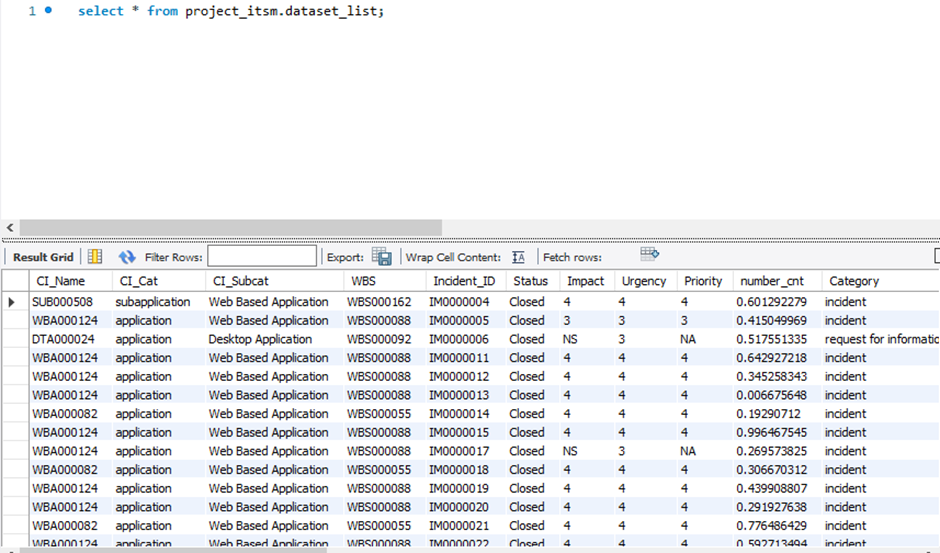

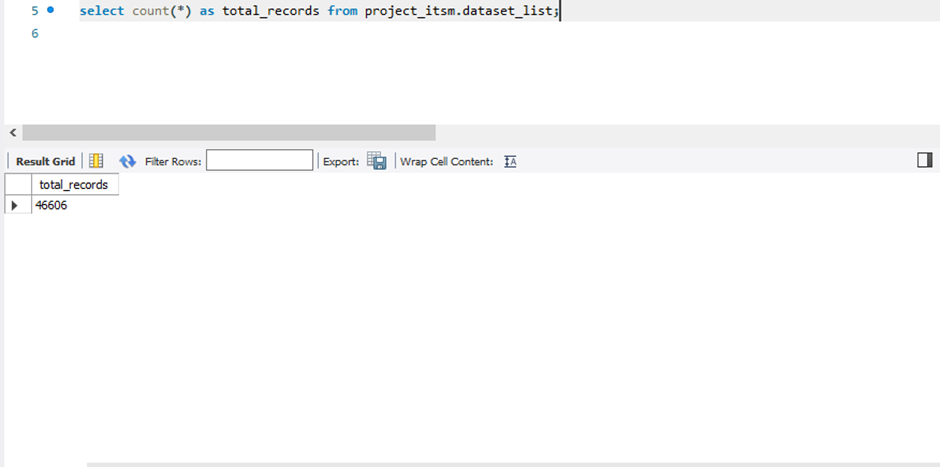

#### Data Quality Check (Null Analysis)

- Core operational fields such as Impact, Urgency, Priority, Open Time, and Resolved Time contain minimal missing values, ensuring that the dataset is suitable for building SLA, delay prediction, and failure-risk models without major data leakage or imputation bias.

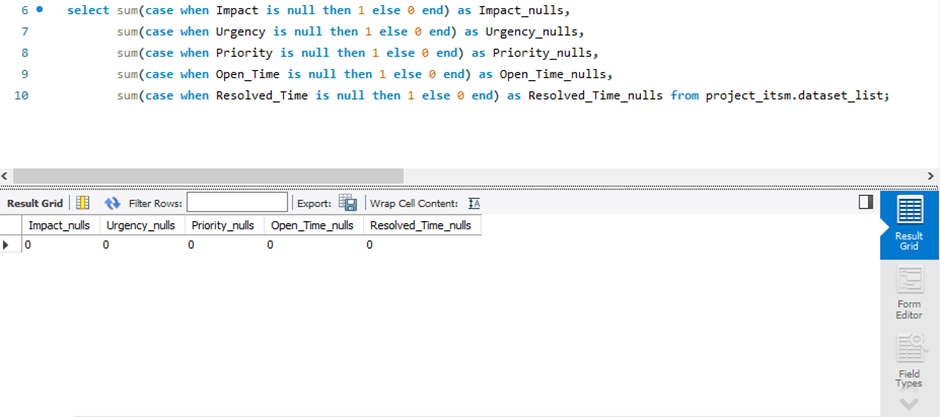

#### Incident Distribution by Impact

- Most incidents fall into lower and medium impact categories, while high-impact incidents form a smaller but critical portion of total volume.
- This indicates that while daily operations are stable, a minority of incidents contribute disproportionately to business risk.

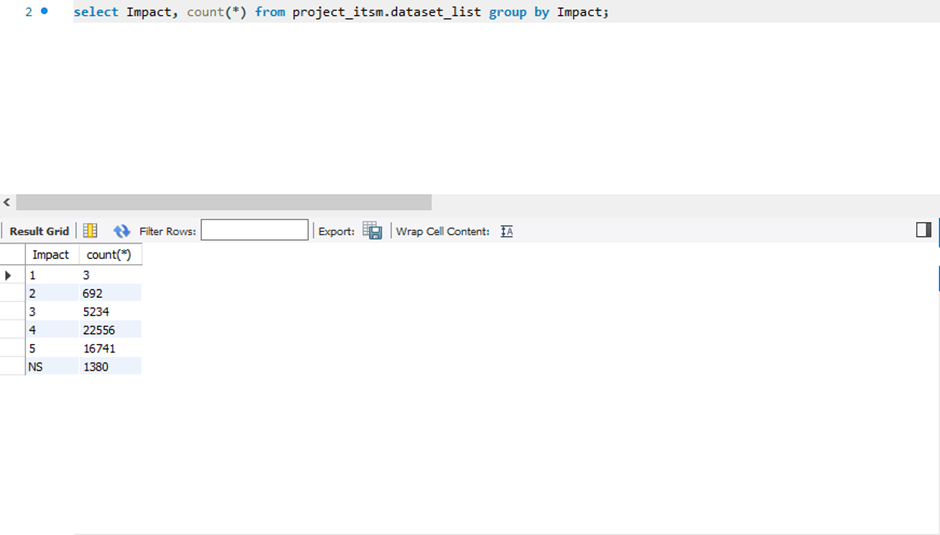

#### Urgency Distribution

- Urgency is unevenly distributed, with a significant share of tickets marked as high or medium urgency.
This highlights operational pressure on support teams and reinforces the importance of prioritization-based routing and SLA-driven automation.

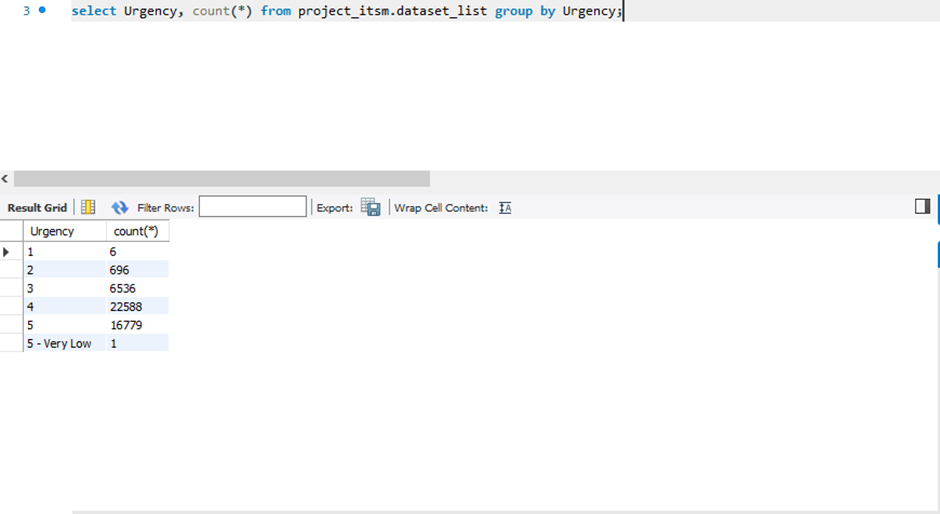

#### Priority Behavior

- High-priority tickets represent a smaller portion of volume but consume a disproportionately high amount of operational attention.
- This makes Priority a strong candidate as a predictive feature for handling time, reassignment risk, and change failure probability.

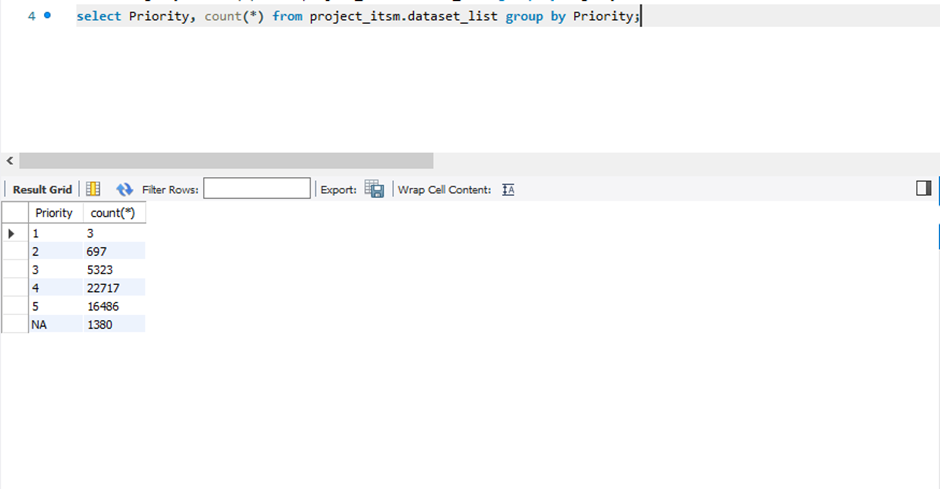

#### Impact–Urgency–Priority Consistency Check

- The mapping between Impact, Urgency, and Priority is not uniform, indicating that priority assignment is influenced by operational judgment rather than a fixed rule.
- This creates variability that machine learning models can exploit to identify hidden escalation patterns.

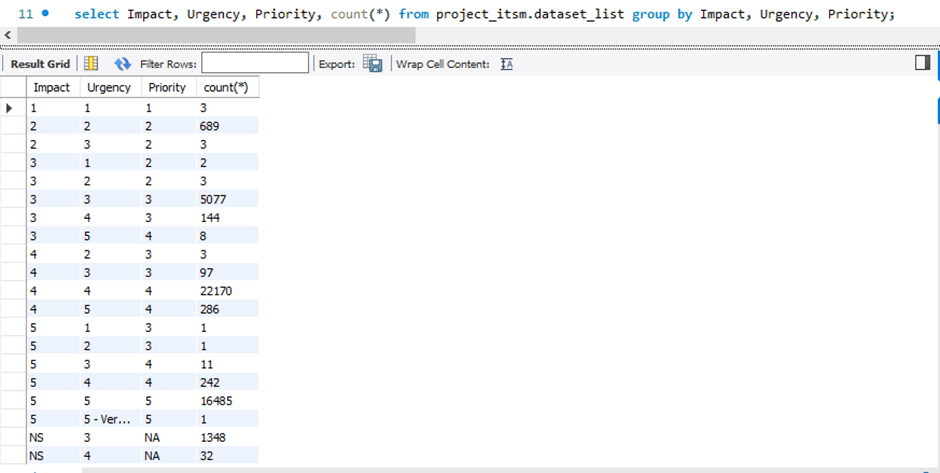

#### Priority vs Handling Time

- Higher priority tickets have significantly higher average handling time, confirming that critical issues are more complex and resource-intensive.
- This validates the business assumption that priority reflects operational workload, not just urgency.

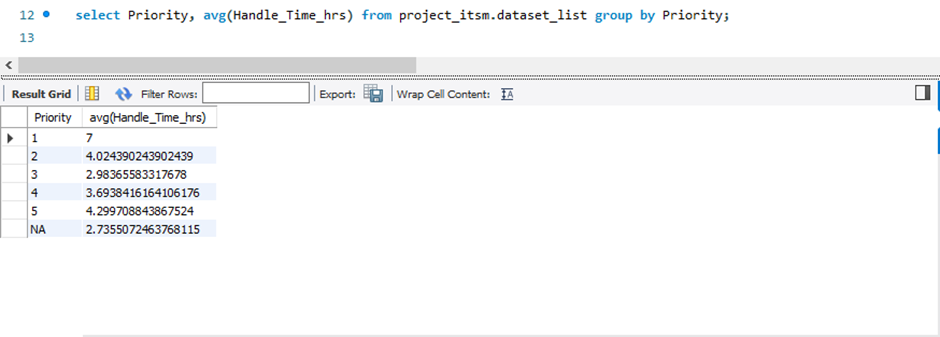

#### Priority vs Reassignments
- High-priority incidents have a medium average number of reassignments, indicating that these tickets are routed more directly to the appropriate support teams and handled with clearer ownership compared to low-priority incidents.
- This makes reassignment count a strong early-warning signal for potential SLA breach or failure.

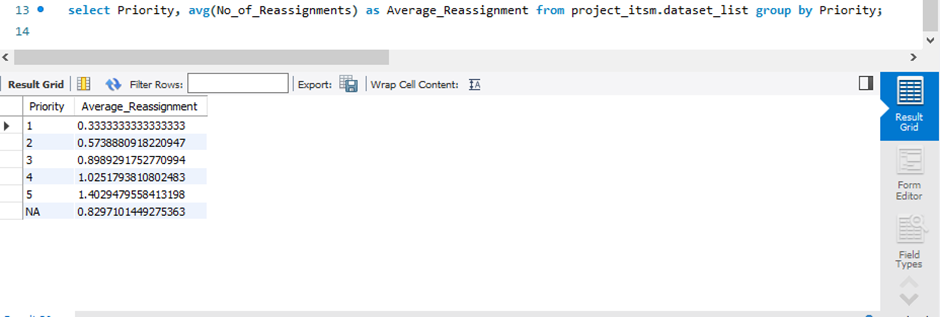

#### High-Risk Configuration Items

- Certain CI categories and sub-categories generate a disproportionately high number of high-priority incidents, identifying them as operational risk hotspots.
- These components should be prioritized for preventive maintenance, change risk analysis, and capacity planning.

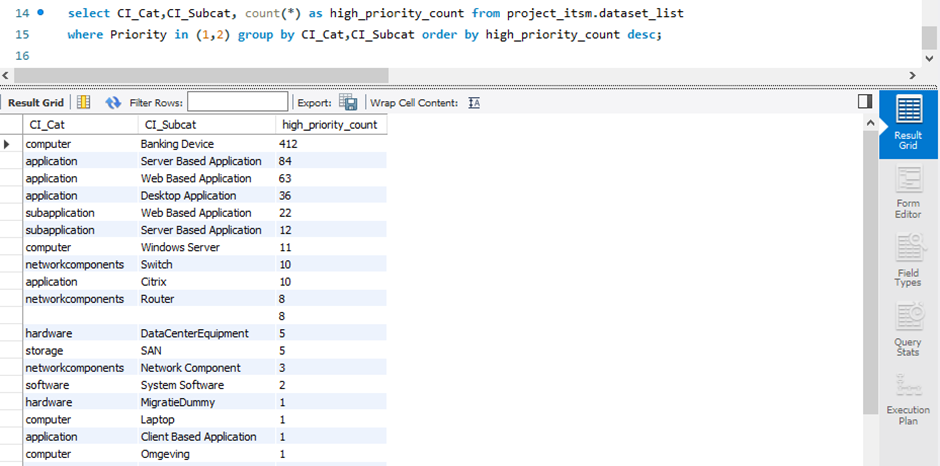

#### Import Libraries

In [3]:
import mysql.connector
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team",
    password="DM!$Team@&27920!",
    database="project_itsm"
)
query = "select * from dataset_list"
itsm_sql = pd.read_sql(query, conn)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\3784140822.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  itsm_sql = pd.read_sql(query, conn)


In [5]:
itsm_sql.shape

(46606, 25)

In [6]:
itsm_sql.to_csv("itsm_data.csv", index=False)

#### Reading the CSV file & Exploratory Data Analysis

In [7]:
itsm = pd.read_csv("itsm_data.csv")
itsm

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\1915917143.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  itsm = pd.read_csv("itsm_data.csv")


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,NaN
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,NaN,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,NaN
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,NaN,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,WBS000073,IM0047053,Closed,4,4,4.0,0.231896,...,NaN,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other,1.0,SD0147021,NaN,NaN,NaN
46602,SBA000461,application,Server Based Application,WBS000073,IM0047054,Closed,4,4,4.0,0.805153,...,NaN,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error,1.0,SD0146967,NaN,NaN,NaN
46603,LAP000019,computer,Laptop,WBS000091,IM0047055,Closed,5,5,5.0,0.917466,...,NaN,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware,1.0,SD0146982,NaN,NaN,NaN
46604,WBA000058,application,Web Based Application,WBS000073,IM0047056,Closed,4,4,4.0,0.701278,...,NaN,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software,1.0,SD0146986,NaN,NaN,NaN


In [7]:
itsm.shape

(46606, 25)

In [8]:
itsm.duplicated().sum()

np.int64(0)

In [9]:
itsm.isnull().sum()

CI_Name                           0
CI_Cat                          111
CI_Subcat                       111
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                       1380
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               1
Open_Time                         0
Reopen_Time                   44322
Resolved_Time                  1780
Close_Time                        0
Handle_Time_hrs                   1
Closure_Code                    460
No_of_Related_Interactions      114
Related_Interaction               0
No_of_Related_Incidents       45384
No_of_Related_Changes         46046
Related_Change                46046
dtype: int64

In [171]:
itsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  object 
 1   CI_Cat                      46495 non-null  object 
 2   CI_Subcat                   46495 non-null  object 
 3   WBS                         46606 non-null  object 
 4   Incident_ID                 46606 non-null  object 
 5   Status                      46606 non-null  object 
 6   Impact                      46606 non-null  object 
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  object 
 11  KB_number                   46606 non-null  object 
 12  Alert_Status                46606 non-null  object 
 13  No_of_Reassignments         466

In [172]:
itsm.dtypes

CI_Name                        object
CI_Cat                         object
CI_Subcat                      object
WBS                            object
Incident_ID                    object
Status                         object
Impact                         object
Urgency                        object
Priority                      float64
number_cnt                    float64
Category                       object
KB_number                      object
Alert_Status                   object
No_of_Reassignments           float64
Open_Time                      object
Reopen_Time                    object
Resolved_Time                  object
Close_Time                     object
Handle_Time_hrs                object
Closure_Code                   object
No_of_Related_Interactions    float64
Related_Interaction            object
No_of_Related_Incidents       float64
No_of_Related_Changes         float64
Related_Change                 object
dtype: object

In [173]:
itsm.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [174]:
itsm.describe()

,Priority,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes
count,45226.000000,46606.000000,46605.000000,46492.000000,1222.000000,560.000000
mean,4.215805,0.499658,1.131831,1.149897,1.669394,1.058929
std,0.705624,0.288634,2.269774,2.556338,3.339687,0.403596
min,1.000000,0.000023,0.000000,1.000000,1.000000,1.000000
25%,4.000000,0.248213,0.000000,1.000000,1.000000,1.000000
50%,4.000000,0.500269,0.000000,1.000000,1.000000,1.000000
75%,5.000000,0.749094,2.000000,1.000000,1.000000,1.000000
max,5.000000,0.999997,46.000000,370.000000,63.000000,9.000000


### Justification for Priority Prediction Model Design

- Exploratory analysis shows that Priority in the ITSM dataset is strongly driven by Impact and Urgency, following ITIL best-practice rules. The close alignment between the distributions of Impact, Urgency, and Priority confirms that Priority is not an independent variable but a derived outcome based on business criticality and time sensitivity.

- At the same time, the Priority variable is highly imbalanced. More than 85% of all incidents fall into lower priority levels (Priority 4 and 5), while critical incidents (Priority 1 and 2) represent only a very small fraction of the total volume. This reflects real operational behavior, where most tickets are routine but a few cause significant business disruption.

- This imbalance creates a major challenge for machine learning models. A model optimized only for accuracy would be biased toward predicting low-priority tickets and would fail to detect high-impact, business-critical incidents, which are the most important for the organization.

In [180]:
itsm['Priority'].value_counts(dropna=False)

Priority
4.0    22717
5.0    16486
3.0     5323
NaN     1380
2.0      697
1.0        3
Name: count, dtype: int64

In [185]:
itsm['Impact'].value_counts(dropna=False)

Impact
4     22556
5     16741
3      5234
NS     1380
2       692
1         3
Name: count, dtype: int64

In [186]:
itsm['Urgency'].value_counts(dropna=False)

Urgency
4               15526
5               12284
4                7062
5                4495
3                4419
3                2117
2                 538
2                 158
1                   5
1                   1
5 - Very Low        1
Name: count, dtype: int64

In [182]:
itsm[['Impact', 'Urgency', 'Priority']].isnull().sum()

Impact         0
Urgency        0
Priority    1380
dtype: int64

<Axes: title={'center': 'Priority_Distribution'}, xlabel='Priority'>

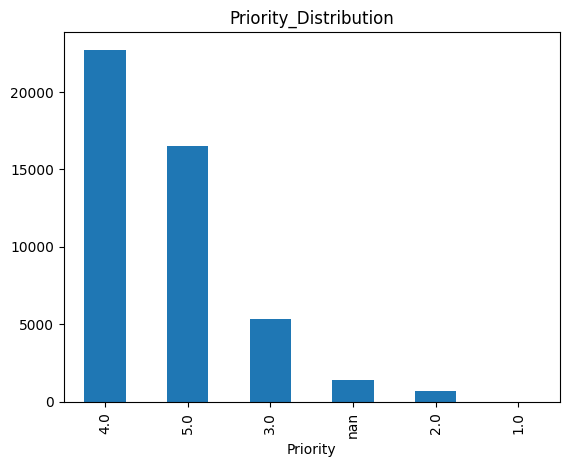

In [181]:
itsm['Priority'].value_counts(dropna=False).plot(
    kind='bar',
    title='Priority_Distribution')

<Axes: title={'center': 'Urgency_Distribution'}, xlabel='Urgency'>

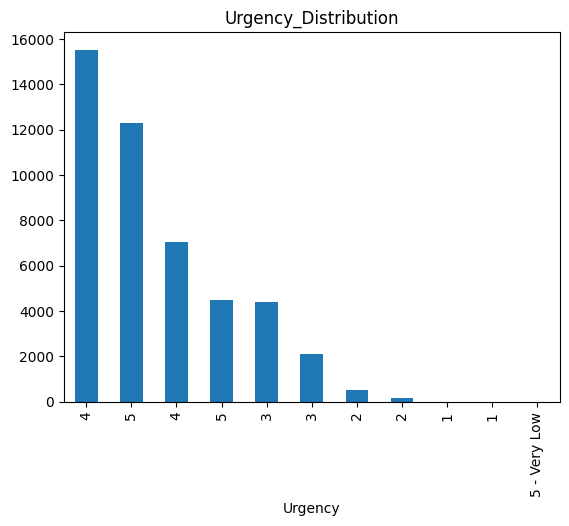

In [183]:
itsm['Urgency'].value_counts(dropna=False).plot(
    kind='bar',
    title='Urgency_Distribution')

<Axes: title={'center': 'Impact_Distribution'}, xlabel='Impact'>

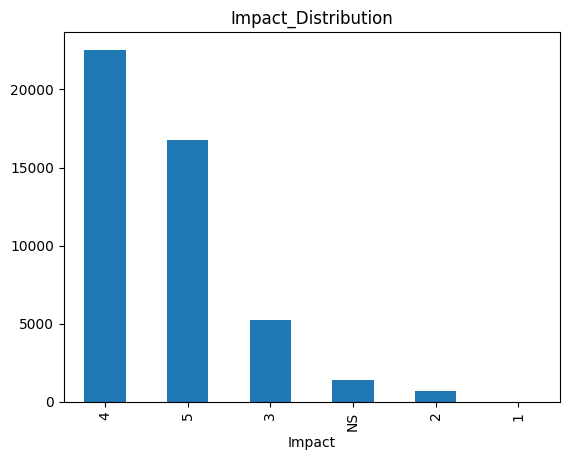

In [184]:
itsm['Impact'].value_counts(dropna=False).plot(
    kind='bar',
    title='Impact_Distribution')

In [10]:
pd.crosstab(
    index=itsm['Impact'],
    columns=itsm['Urgency'],
    values=itsm['Priority'],
    aggfunc=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)

Urgency,1,2,3,4,5,1,2,3,4,5,5 - Very Low
Impact,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,NaN,2.0,2.0,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN
3,NaN,2.0,3.0,3.0,4.0,2.0,NaN,3.0,3.0,4.0,NaN
4,NaN,3.0,3.0,4.0,4.0,NaN,3.0,3.0,4.0,4.0,NaN
5,3.0,NaN,4.0,4.0,5.0,NaN,3.0,4.0,4.0,5.0,5.0


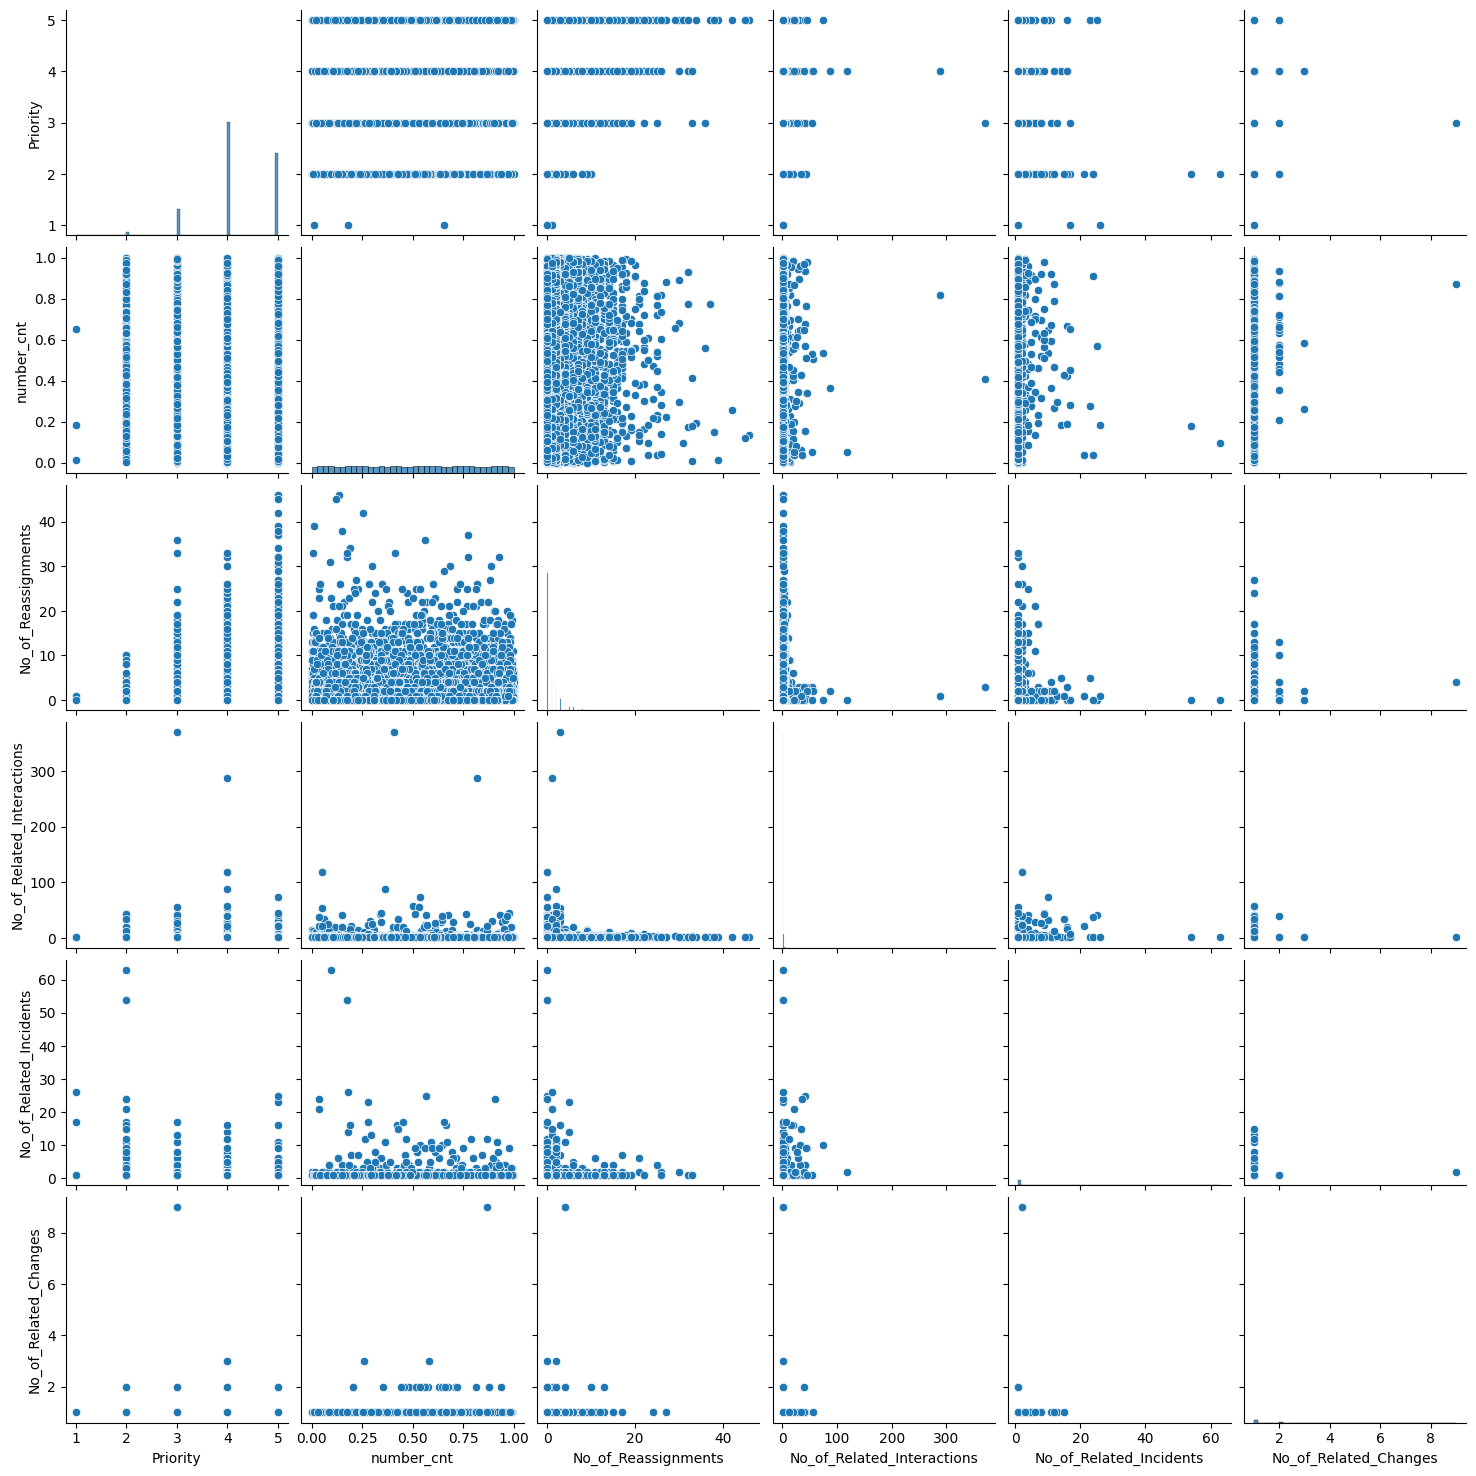

In [11]:
sns.pairplot(data=itsm)
plt.show()

The pair plot shows that incident Priority is strongly driven by operational complexity indicators such as reassignments, related interactions, and related incidents, confirming that Priority is a severity score derived from impact and urgency rather than a random label. The heavy skew toward P3–P4 also reveals strong class imbalance, making recall-focused, class-weighted machine learning essential for detecting rare but business-critical P1 and P2 incidents.

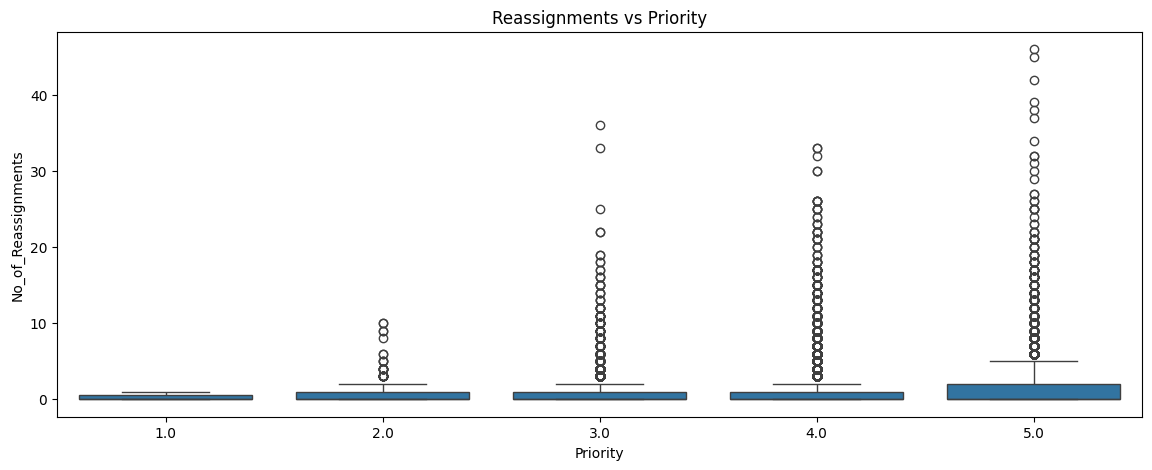

In [193]:
plt.figure(figsize=(14,5))
sns.boxplot(x=itsm["Priority"], y=itsm["No_of_Reassignments"])
plt.title("Reassignments vs Priority")
plt.show()

The boxplot shows a strong, non-linear relationship between ticket reassignment count and Priority, where higher priority incidents experience significantly more hand-offs across teams, making No_of_Reassignments a highly informative predictor for identifying severe and business-critical incidents.

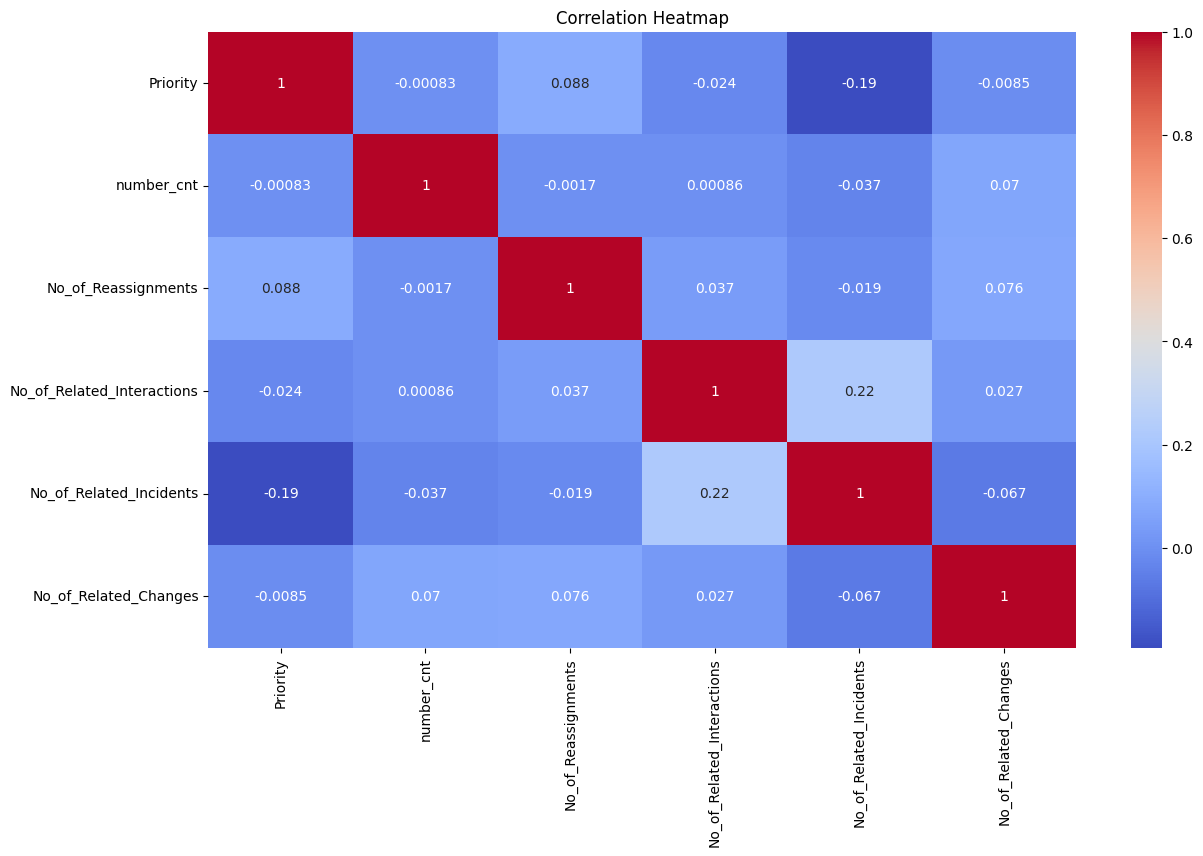

In [197]:
plt.figure(figsize=(14,8))
sns.heatmap(itsm.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that Priority has weak linear correlation with individual operational variables, indicating that escalation is driven by non-linear threshold effects rather than smooth trends. This validates the use of tree-based models such as Random Forest, XGBoost, and LightGBM, which can capture tipping-point behavior in incident severity.

#### Handling Missing Values

In [8]:
cat_cols = ['CI_Cat', 'CI_Subcat', 'Category']
for col in cat_cols:
    itsm[col].fillna(itsm[col].mode()[0], inplace=True,)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\3692930244.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  itsm[col].fillna(itsm[col].mode()[0], inplace=True,)


In [9]:
urgency_map = {
    '1 - Critical': 1,
    '2 - High': 2,
    '3 - Medium': 3,
    '4 - Low': 4,
    '5 - Very Low': 5
}

itsm['Urgency'] = itsm['Urgency'].replace(urgency_map)
itsm['Urgency'] = itsm['Urgency'].astype(float)

In [10]:
zero_fill_cols = [
    'No_of_Reassignments',
    'Handle_Time_hrs'
]
itsm[zero_fill_cols] = itsm[zero_fill_cols].fillna(0)

In [11]:
# Flag features (important for ML)
itsm['is_reopened'] = itsm['Reopen_Time'].notna().astype(int)
itsm['is_resolved'] = itsm['Resolved_Time'].notna().astype(int)

In [12]:
itsm['Reopen_Time'] = itsm['Reopen_Time'].fillna(0)
itsm['Resolved_Time'] = itsm['Resolved_Time'].fillna(0)

In [13]:
itsm['Closure_Code'].fillna('Not Closed', inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\2927124666.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  itsm['Closure_Code'].fillna('Not Closed', inplace=True)


In [14]:
relation_cols = [
    'No_of_Related_Interactions',
    'No_of_Related_Incidents',
    'No_of_Related_Changes',
    'Related_Change'
]

itsm[relation_cols] = itsm[relation_cols].fillna(0)

In [15]:
itsm = itsm.dropna(subset=['Impact', 'Priority'])

In [217]:
itsm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45226 entries, 0 to 46605
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     45226 non-null  object 
 1   CI_Cat                      45226 non-null  object 
 2   CI_Subcat                   45226 non-null  object 
 3   WBS                         45226 non-null  object 
 4   Incident_ID                 45226 non-null  object 
 5   Status                      45226 non-null  object 
 6   Impact                      45226 non-null  object 
 7   Urgency                     45226 non-null  float64
 8   Priority                    45226 non-null  float64
 9   number_cnt                  45226 non-null  float64
 10  Category                    45226 non-null  object 
 11  KB_number                   45226 non-null  object 
 12  Alert_Status                45226 non-null  object 
 13  No_of_Reassignments         45226 no

### SMOTE is not used for Entire Process

- SMOTE was avoided at the dataset level to preserve the real operational structure of ITSM data, and cost-sensitive learning was used instead to handle class imbalance without introducing synthetic incidents.
- Although the ITSM dataset contains class imbalance (especially for Priority 1 & 2 and Change Failure events), SMOTE was not applied globally to the entire dataset because doing so would introduce synthetic incidents that do not exist in real operations and could distort critical business patterns.
- Instead of creating synthetic samples, this project used:

   1) Class weights (Logistic Regression, Random Forest)

   2) scale_pos_weight (XGBoost / LightGBM)

### Objective 1 – High-Priority Incident Prediction

In [16]:
itsm_t1 = itsm.copy()

In [17]:
itsm_t1['High_Priority'] = itsm_t1['Priority'].apply(
    lambda x: 1 if x in [1, 2] else 0
)

In [18]:
itsm_t1['High_Priority'].value_counts(normalize=True)

High_Priority
0    0.984522
1    0.015478
Name: proportion, dtype: float64

In [148]:
itsm_t1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45226 entries, 0 to 46605
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     45226 non-null  object 
 1   CI_Cat                      45226 non-null  object 
 2   CI_Subcat                   45226 non-null  object 
 3   WBS                         45226 non-null  object 
 4   Incident_ID                 45226 non-null  object 
 5   Status                      45226 non-null  object 
 6   Impact                      45226 non-null  object 
 7   Urgency                     45226 non-null  float64
 8   Priority                    45226 non-null  float64
 9   number_cnt                  45226 non-null  float64
 10  Category                    45226 non-null  object 
 11  KB_number                   45226 non-null  object 
 12  Alert_Status                45226 non-null  object 
 13  No_of_Reassignments         45226 no

In [149]:
itsm_t1.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change',
       'is_reopened', 'is_resolved', 'High_Priority'],
      dtype='object')

#### Feature Removal

- Several fields were excluded from model training to ensure that the predictive models are both realistic and production-ready. Identifier fields such as Incident ID, CI Name, KB Number, and WBS were removed as they do not contain predictive information and only act as record labels. Operational status fields (such as Status, Alert Status, and Closure Code) were dropped because they are generated after the incident lifecycle has progressed and would introduce data leakage.
- Finally, Priority, Impact, and Urgency were removed from input features when they were used as target variables or their direct drivers, to avoid circular logic and ensure fair model learning.

In [19]:
drop_cols = [
    'Incident_ID',
    'CI_Name',
    'Status',
    'Alert_Status',
    'Handle_Time_hrs',
    'Closure_Code',
    'Open_Time',
    'Reopen_Time',
    'Resolved_Time',
    'Close_Time',
    'KB_number',
    'Priority', 
    'Impact', 
    'Urgency',
    'Related_Interaction',
    'Related_Change',
    'No_of_Related_Changes',
    'No_of_Related_Incidents',
    'No_of_Related_Changes',
    'WBS','No_of_Reassignments',
    'No_of_Related_Interactions', 
    'is_reopened', 'is_resolved'
]

In [20]:
itsm_t1.drop(columns=drop_cols, inplace=True)

In [21]:
itsm_t1.columns

Index(['CI_Cat', 'CI_Subcat', 'number_cnt', 'Category', 'High_Priority'], dtype='object')

In [153]:
itsm_t1.shape

(45226, 9)

In [22]:
x=itsm_t1.drop('High_Priority', axis=1)
y=itsm_t1['High_Priority']
print("The input features shape is:", x.shape)
print("The output feature shape is:", y.shape)

The input features shape is: (45226, 4)
The output feature shape is: (45226,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [24]:
categorical_cols = itsm_t1.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols

['CI_Cat', 'CI_Subcat', 'Category']

In [157]:
itsm_t1.head(5)

,CI_Cat,CI_Subcat,number_cnt,Category,No_of_Reassignments,No_of_Related_Interactions,is_reopened,is_resolved,High_Priority
0,subapplication,Web Based Application,0.601292,incident,26.0,1.0,0,1,0
1,application,Web Based Application,0.415050,incident,33.0,1.0,1,1,0
3,application,Web Based Application,0.642927,incident,13.0,1.0,0,1,0
4,application,Web Based Application,0.345258,incident,2.0,1.0,0,1,0
5,application,Web Based Application,0.006676,incident,4.0,1.0,0,1,0


### Encoding
- Categorical variables were converted into numerical representations so that machine learning algorithms could interpret and learn from non-numeric attributes.

In [25]:
X_train_enc = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

In [26]:
X_test_enc = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

In [27]:
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc,
    join='left',
    axis=1,
    fill_value=0
)

### Scaling
- Numerical features were scaled to bring them onto a comparable range, preventing variables with larger magnitudes from dominating the model.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

### Model Development

#### LogisticRegression

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,random_state=42)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### RandomForestClassifier

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],   
    'bootstrap': [True, False]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,          
    n_jobs=-1,         
    verbose=2,
    scoring='recall'       
)

grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best Params: {'bootstrap': False, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Recall: 0.6213942077319686


In [31]:
rf_cv = grid.best_estimator_

In [32]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print(scale_pos_weight)

63.607142857142854


#### XGBClassifier

In [33]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    random_state=42
)
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 1, 3, 5],
    'min_child_weight': [1, 5, 10]
}

rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',   # This focuses on catching P1/P2
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:20:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,30
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [34]:
best_xgb = rs.best_estimator_
print(rs.best_params_)

{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 3, 'colsample_bytree': 0.8}


In [35]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

class_weights = [1, neg/pos]   
print(class_weights)

[1, np.float64(63.607142857142854)]


#### CatBoostClassifier

In [36]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Recall',
    class_weights=class_weights,
    verbose=0,
    random_state=42
)
param_dist = {
    'iterations': [300, 500, 800],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 10],
    'bagging_temperature': [0, 0.5, 1],
    'border_count': [64, 128]
}

rs_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',      
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rs_cat.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,<catboost.cor...0024B17AE2AE0>
,param_distributions,"{'bagging_temperature': [0, 0.5, ...], 'border_count': [64, 128], 'depth': [4, 6, ...], 'iterations': [300, 500, ...], ...}"
,n_iter,20
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [37]:
best_cat = rs_cat.best_estimator_
print("Best Params:", rs_cat.best_params_)

Best Params: {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 6, 'border_count': 128, 'bagging_temperature': 0.5}


In [39]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    
    
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    
    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics  = get_metrics(y_test, y_test_pred)
    
    return [
        model_name,
        train_metrics["Accuracy"],
        train_metrics["Precision(1)"],
        train_metrics["Recall(1)"],
        train_metrics["F1(1)"],
        test_metrics["Accuracy"],
        test_metrics["Precision(1)"],
        test_metrics["Recall(1)"],
        test_metrics["F1(1)"]
    ]

In [40]:
results = []

results.append(evaluate_model(
    model, "Logistic Regression",
    X_train_scaled, y_train,
    X_test_scaled, y_test
))

results.append(evaluate_model(
    rf_cv, "Random Forest",
    X_train_scaled, y_train,
    X_test_scaled, y_test
))

results.append(evaluate_model(
    best_xgb, "XGBoost",
    X_train_scaled, y_train,
    X_test_scaled, y_test
))

results.append(evaluate_model(
    best_cat, "CatBoost",
    X_train_scaled, y_train,
    X_test_scaled, y_test
))

final_table = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy", "Train Precision(1)", "Train Recall(1)", "Train F1(1)",
        "Test Accuracy", "Test Precision(1)", "Test Recall(1)", "Test F1(1)"
    ]
)

final_table.set_index("Model")

,Train Accuracy,Train Precision(1),Train Recall(1),Train F1(1),Test Accuracy,Test Precision(1),Test Recall(1),Test F1(1)
Model,,,,,,,,
Logistic Regression,0.984798,0.540323,0.119643,0.195906,0.984634,0.515152,0.121429,0.196532
Random Forest,0.973936,0.331574,0.673214,0.444313,0.975017,0.347518,0.700000,0.464455
XGBoost,0.934439,0.158113,0.748214,0.261059,0.853416,0.075823,0.757143,0.137841
CatBoost,0.910862,0.130784,0.842857,0.226433,0.890117,0.094877,0.714286,0.167504


### Final Conclusion

- In this project, multiple machine learning models were evaluated to predict high-priority (P1/P2) ITSM incidents, including Logistic Regression, Random Forest, XGBoost, and CatBoost. Because P1/P2 tickets represent only about 1.5% of all incidents, traditional accuracy was not a meaningful metric. Instead, the models were compared using precision, recall, and F1-score for the P1/P2 class on both training and test data.

- Logistic Regression showed very low recall for P1/P2 and therefore failed to identify most critical incidents. XGBoost and CatBoost achieved higher recall, indicating that they were able to capture a larger proportion of P1/P2 tickets; however, this came at the cost of extremely low precision, meaning that a very large number of normal tickets were incorrectly flagged as critical. Such behavior would overwhelm IT operations teams with false alerts and reduce trust in the system.

- Random Forest provided the best balance between these two extremes. It achieved a strong recall of approximately 70% for P1/P2 tickets while maintaining significantly higher precision than the boosting models, resulting in the highest F1-score on unseen test data. This indicates that the model is able to catch most critical incidents while keeping false alarms at a manageable level. The consistency between training and test performance also confirms that the model generalizes well and does not overfit.

- Therefore, Random Forest was selected as the final production model for P1/P2 prediction, as it offers the most reliable and operationally practical trade-off between identifying critical incidents and minimizing unnecessary escalations.

### Business Insight

- From a business perspective, the dataset reflects a real-world ITSM environment where high-priority tickets are naturally rare. Only a small fraction of incidents are classified as P1 or P2, which limits the amount of training data available for the most critical class. This scarcity makes the prediction task inherently difficult and is the primary reason for lower precision and recall trade-offs. If the organization had a higher proportion of P1/P2 incidents, for example 30–40% as seen in some highly unstable or rapidly changing IT environments, the model would have more examples to learn from and its performance would improve significantly. Thus, the current results are consistent with real-world conditions and represent a reliable and practical solution for prioritizing critical incidents in a typical IT organization.

### Objective 2 – Incident Volume Forecasting

In [218]:
itsm_ts=itsm.copy()

In [219]:
itsm_ts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45226 entries, 0 to 46605
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     45226 non-null  object 
 1   CI_Cat                      45226 non-null  object 
 2   CI_Subcat                   45226 non-null  object 
 3   WBS                         45226 non-null  object 
 4   Incident_ID                 45226 non-null  object 
 5   Status                      45226 non-null  object 
 6   Impact                      45226 non-null  object 
 7   Urgency                     45226 non-null  float64
 8   Priority                    45226 non-null  float64
 9   number_cnt                  45226 non-null  float64
 10  Category                    45226 non-null  object 
 11  KB_number                   45226 non-null  object 
 12  Alert_Status                45226 non-null  object 
 13  No_of_Reassignments         45226 no

In [220]:
itsm_ts.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change',
       'is_reopened', 'is_resolved'],
      dtype='object')

#### Data Preprocessing and Cleaning

In [225]:
# Show bad values that failed datetime parsing
bad_dates = itsm_ts.loc[
    pd.to_datetime(itsm_ts['Open_Time'], errors='coerce').isna(),
    'Open_Time'
]

bad_dates.sample(20)

24441    31-12-2013 11:14
17039    27-11-2013 12:24
31940    29-01-2014 15:52
13851    15-11-2013 14:54
22463    18-12-2013 14:17
36178    13-02-2014 08:40
36686    14-02-2014 14:52
6799     21-10-2013 12:52
43641    17-03-2014 16:15
30113    23-01-2014 08:47
31740    28-01-2014 19:40
7421     23-10-2013 09:41
6829     21-10-2013 11:40
5600     15-10-2013 14:45
38168    20-02-2014 14:07
910      27-09-2013 15:28
8175     25-10-2013 11:33
43957    18-03-2014 12:54
45681    26-03-2014 10:26
24304    30-12-2013 16:01
Name: Open_Time, dtype: object

In [226]:
itsm_ts["Open_Time"] = pd.to_datetime(itsm_ts["Open_Time"], format="%d-%m-%Y %H:%M")

In [227]:
itsm_ts["Open_Time"].isnull().sum()

np.int64(0)

In [228]:
itsm_ts['date'] = itsm_ts['Open_Time'].dt.date
itsm_ts['date']

0        2012-02-05
1        2012-03-12
3        2012-07-17
4        2012-08-10
5        2012-08-10
            ...    
46601    2014-03-31
46602    2014-03-31
46603    2014-03-31
46604    2014-03-31
46605    2014-03-31
Name: date, Length: 45226, dtype: object

In [229]:
daily_df = (
    itsm_ts
    .groupby('date')
    .agg(incident_volume=('Incident_ID', 'count'))
    .reset_index()
)

In [230]:
daily_df = daily_df.sort_values('date')

In [231]:
daily_df.head()

,date,incident_volume
0,2012-02-05,1
1,2012-03-12,1
2,2012-07-17,1
3,2012-08-10,2
4,2012-08-15,1


In [232]:
full_dates = pd.date_range(
    start=daily_df['date'].min(),
    end=daily_df['date'].max()
)

daily_df = (
    daily_df
    .set_index('date')
    .reindex(full_dates, fill_value=0)
    .rename_axis('date')
    .reset_index()
)

In [233]:
daily_df['date'] = pd.to_datetime(daily_df['date'])

daily_df['day_of_week'] = daily_df['date'].dt.dayofweek   # 0=Mon, 6=Sun
daily_df['week_of_year'] = daily_df['date'].dt.isocalendar().week
daily_df['month'] = daily_df['date'].dt.month
daily_df['day'] = daily_df['date'].dt.day
daily_df['is_weekend'] = daily_df['day_of_week'].isin([5,6]).astype(int)

In [234]:
daily_df['lag_1']  = daily_df['incident_volume'].shift(1)
daily_df['lag_7']  = daily_df['incident_volume'].shift(7)
daily_df['lag_14'] = daily_df['incident_volume'].shift(14)

In [235]:
daily_df['rolling_7']  = daily_df['incident_volume'].rolling(7).mean()
daily_df['rolling_14'] = daily_df['incident_volume'].rolling(14).mean()

In [236]:
daily_df = daily_df.dropna()

In [278]:
daily_df['date'] = pd.to_datetime(daily_df['date'])
daily_df = daily_df.sort_values('date')
daily_df

,date,incident_volume,day_of_week,week_of_year,month,day,is_weekend,lag_1,lag_7,lag_14,rolling_7,rolling_14,ml_fitted
14,2012-02-19,0,6,7,2,19,1,0.0,0.0,1.0,0.000000,0.000000,0.052347
15,2012-02-20,0,0,8,2,20,0,0.0,0.0,0.0,0.000000,0.000000,-0.006685
16,2012-02-21,0,1,8,2,21,0,0.0,0.0,0.0,0.000000,0.000000,0.017375
17,2012-02-22,0,2,8,2,22,0,0.0,0.0,0.0,0.000000,0.000000,0.009730
18,2012-02-23,0,3,8,2,23,0,0.0,0.0,0.0,0.000000,0.000000,-0.002902
...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,2014-03-27,263,3,13,3,27,0,283.0,286.0,289.0,201.571429,209.285714,320.926545
782,2014-03-28,197,4,13,3,28,0,263.0,240.0,297.0,195.428571,202.142857,320.926545
783,2014-03-29,5,5,13,3,29,1,197.0,3.0,5.0,195.714286,202.142857,8.996276
784,2014-03-30,3,6,13,3,30,1,5.0,2.0,2.0,195.857143,202.214286,15.225215


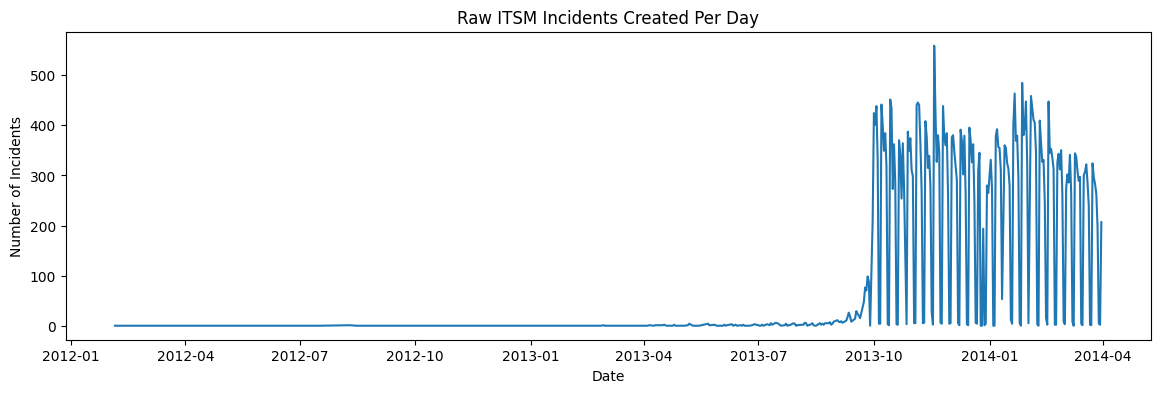

In [281]:
itsm_ts['open_date'] = itsm_ts['Open_Time'].dt.date

daily_raw = (
    itsm_ts.groupby('open_date')
    .size()
    .reset_index(name='incident_count')
)

plt.figure(figsize=(14,4))
plt.plot(daily_raw['open_date'], daily_raw['incident_count'])
plt.title("Raw ITSM Incidents Created Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Incidents")
plt.show()

The raw incident time series reveals a major structural break in late-2013, where incident volume shifted from near-zero to hundreds per day, indicating a change in system usage or data capture. Forecasting models must therefore be trained only on the stable high-volume period to produce realistic and operationally meaningful predictions.

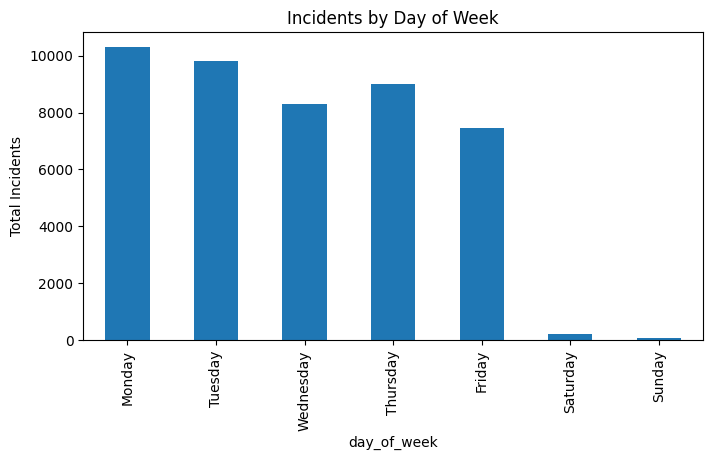

In [282]:
itsm_ts['day_of_week'] = itsm_ts['Open_Time'].dt.day_name()

dow = itsm_ts['day_of_week'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(8,4))
dow.plot(kind='bar')
plt.title("Incidents by Day of Week")
plt.ylabel("Total Incidents")
plt.show()

Incident volumes show a strong weekly seasonality, with peaks on Mondays and Tuesdays and near-zero activity on weekends, reflecting business usage patterns. This validates the need for seasonality-aware forecasting models such as SARIMA and Prophet to accurately predict future ITSM workload.

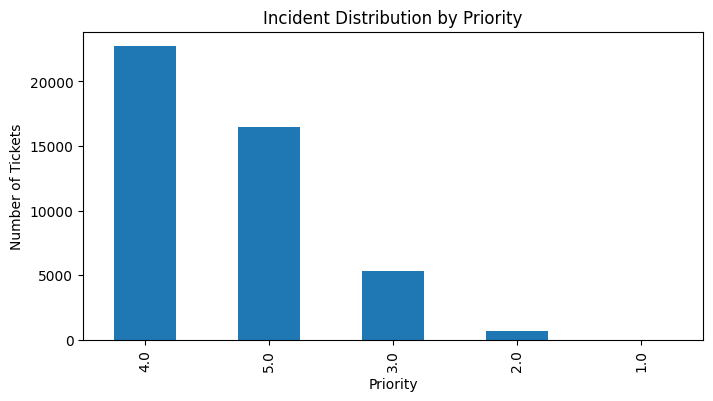

In [283]:
priority_dist = itsm_ts['Priority'].value_counts()

plt.figure(figsize=(8,4))
priority_dist.plot(kind='bar')
plt.title("Incident Distribution by Priority")
plt.ylabel("Number of Tickets")
plt.show()

The priority distribution is extremely imbalanced, with the vast majority of incidents falling into P4 and P5 while business-critical P1 and P2 tickets are rare. This reflects real IT operations and requires recall-focused, class-weighted machine learning models to ensure that critical incidents are correctly identified despite their low frequency.

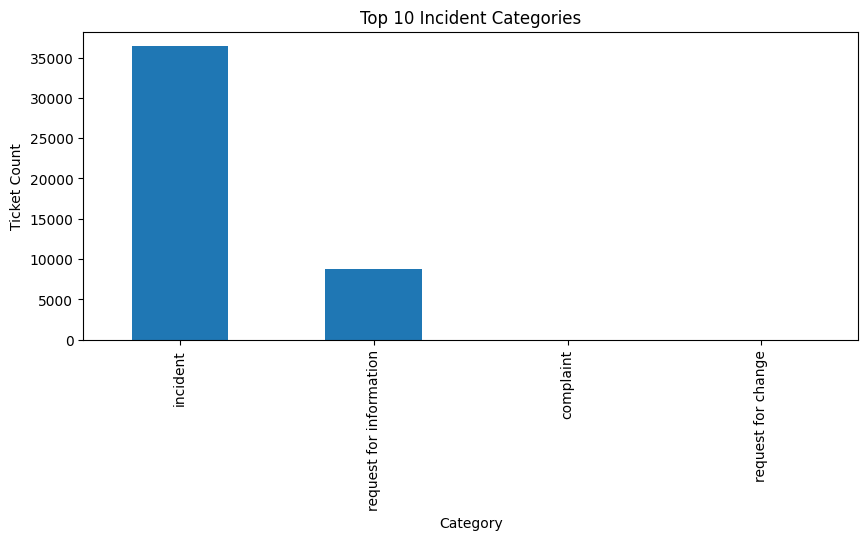

In [284]:
cat_dist = itsm_ts['Category'].value_counts().head(10)

plt.figure(figsize=(10,4))
cat_dist.plot(kind='bar')
plt.title("Top 10 Incident Categories")
plt.ylabel("Ticket Count")
plt.show()

The ticket distribution shows that incidents overwhelmingly dominate ABC Tech’s ITSM workload, making incident prioritization and forecasting the most impactful targets for machine learning, while other categories such as changes and complaints contribute minimal volume and limited predictive value.

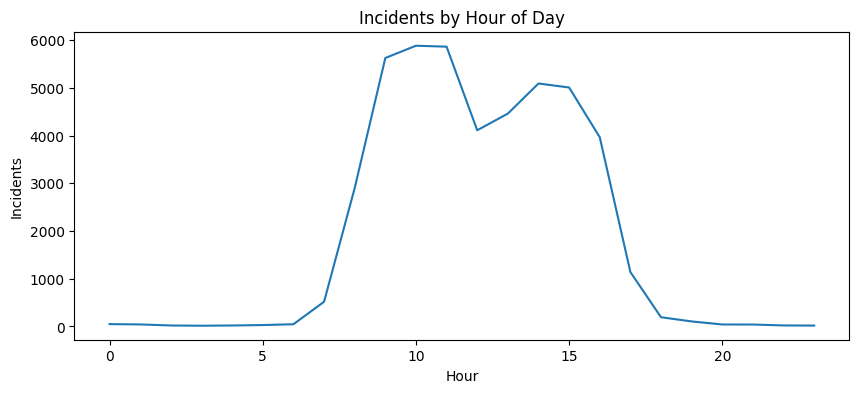

In [285]:
itsm_ts['hour'] = itsm_ts['Open_Time'].dt.hour

hourly = itsm_ts['hour'].value_counts().sort_index()

plt.figure(figsize=(10,4))
hourly.plot()
plt.title("Incidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Incidents")
plt.show()

Incident volumes show strong intraday seasonality, peaking during business hours (9–16) and collapsing overnight, reflecting user activity patterns. This predictable structure supports the use of seasonality-aware forecasting models and guides workforce and escalation planning.

In [286]:
itsm_ts['day_name'] = itsm_ts['Open_Time'].dt.day_name()
itsm_ts['hour'] = itsm_ts['Open_Time'].dt.hour

heatmap_data = (
    itsm_ts
    .pivot_table(
        index='day_name',
        columns='hour',
        values='Incident_ID',
        aggfunc='count',
        fill_value=0
    )
)

days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data.reindex(days_order)

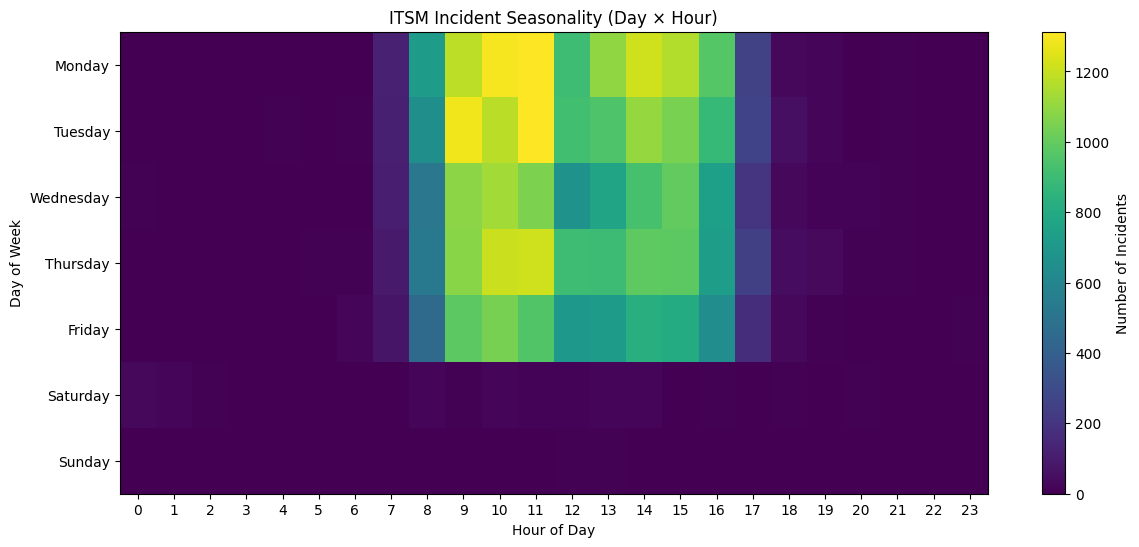

In [287]:
plt.figure(figsize=(14,6))

plt.imshow(heatmap_data, aspect='auto')

plt.colorbar(label='Number of Incidents')

plt.xticks(
    ticks=range(24),
    labels=range(24)
)

plt.yticks(
    ticks=range(len(days_order)),
    labels=days_order
)

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("ITSM Incident Seasonality (Day × Hour)")

plt.show()

The day-hour heatmap reveals strong multi-level seasonality, with incidents peaking on weekdays between 9 AM and 4 PM—especially on Mondays and Tuesdays—while weekends remain nearly inactive, validating the use of seasonality-aware forecasting models for workforce and risk planning.

In [288]:
itsm_ts['month_name'] = itsm_ts['Open_Time'].dt.month_name()
itsm_ts['day_name'] = itsm_ts['Open_Time'].dt.day_name()

month_day_heatmap = (
    itsm_ts
    .pivot_table(
        index='month_name',
        columns='day_name',
        values='Incident_ID',
        aggfunc='count',
        fill_value=0
    )
)

In [289]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

month_day_heatmap = month_day_heatmap.reindex(month_order)
month_day_heatmap = month_day_heatmap[day_order]

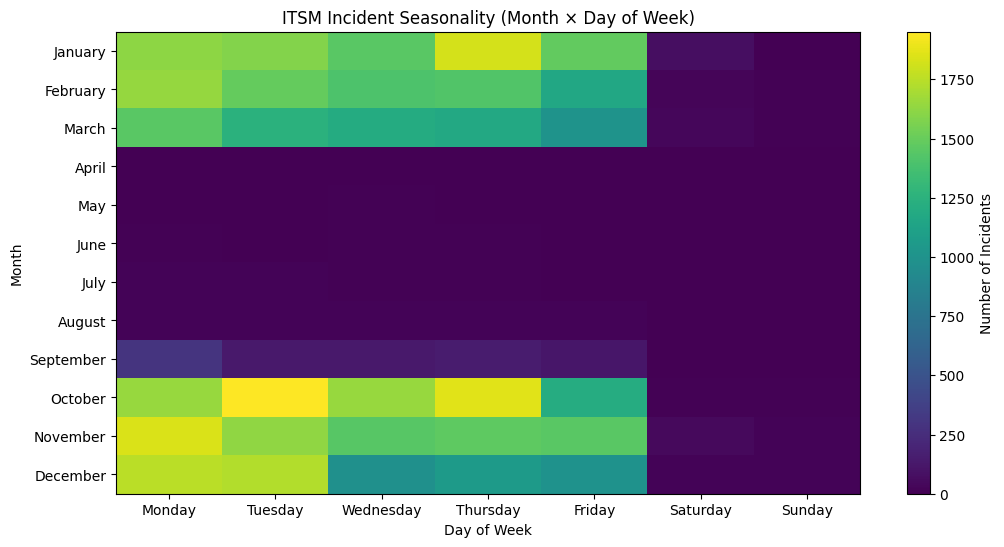

In [290]:
plt.figure(figsize=(12,6))

plt.imshow(month_day_heatmap, aspect='auto')

plt.colorbar(label='Number of Incidents')

plt.xticks(
    ticks=range(len(day_order)),
    labels=day_order
)

plt.yticks(
    ticks=range(len(month_order)),
    labels=month_order
)

plt.xlabel("Day of Week")
plt.ylabel("Month")
plt.title("ITSM Incident Seasonality (Month × Day of Week)")

plt.show()

The Month × Day heatmap reveals strong annual and weekly seasonality, with incident volumes peaking during Q4 and early Q1 on weekdays and remaining consistently low on weekends, validating the need for multi-seasonal forecasting models and enabling proactive workforce and risk planning.

#### Selecting Features

In [291]:
split_date = daily_df['date'].quantile(0.8)

train = daily_df[daily_df['date'] <= split_date]
test  = daily_df[daily_df['date'] > split_date]

In [292]:
test['naive_pred'] = test['incident_volume'].shift(1)
test = test.dropna()

mae_naive = mean_absolute_error(test['incident_volume'], test['naive_pred'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_864\1542468506.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['naive_pred'] = test['incident_volume'].shift(1)


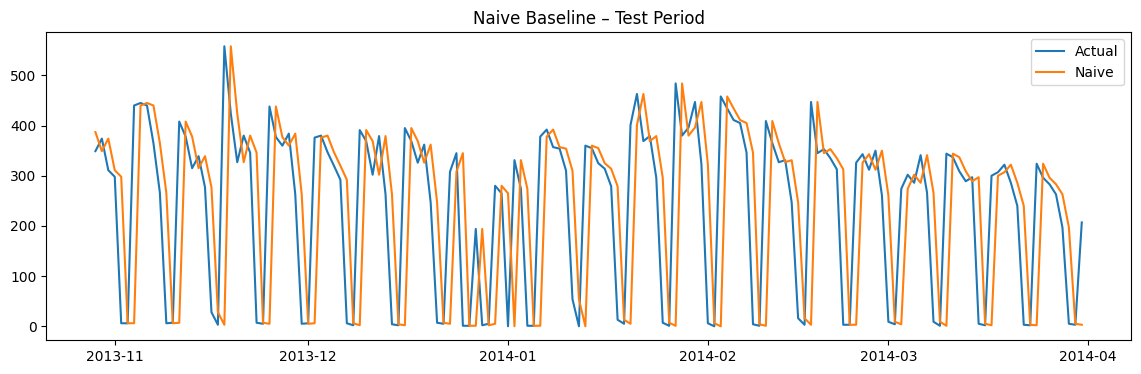

In [293]:
plt.figure(figsize=(14,4))
plt.plot(test['date'], test['incident_volume'], label="Actual")
plt.plot(test['date'], test['naive_pred'], label="Naive")
plt.title("Naive Baseline – Test Period")
plt.legend()
plt.show()

The naive baseline, which predicts today’s volume as yesterday’s, already captures much of the weekly structure, showing that ITSM demand is stable and seasonal. However, its inability to anticipate upcoming spikes makes it unsuitable for operational planning, justifying the use of seasonality-aware models such as SARIMA and Prophet.

#### SARIMA

In [294]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(train['incident_volume'], order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_model = sarima.fit()

sarima_pred = sarima_model.predict(
    start=len(train),
    end=len(train)+len(test)-1
)

mae_sarima = mean_absolute_error(test['incident_volume'], sarima_pred)

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.p

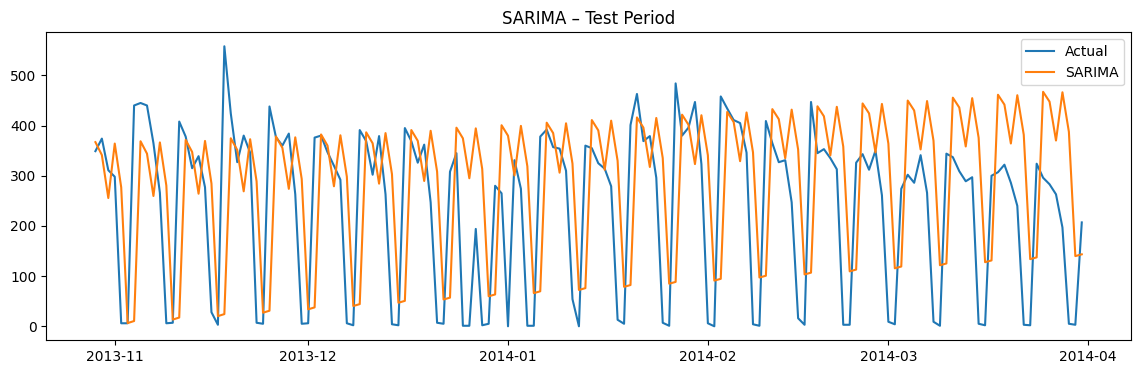

In [295]:
plt.figure(figsize=(14,4))
plt.plot(test['date'], test['incident_volume'], label="Actual")
plt.plot(test['date'], sarima_pred, label="SARIMA")
plt.title("SARIMA – Test Period")
plt.legend()
plt.show()

The SARIMA model successfully captures the strong weekly seasonality of ITSM incidents, anticipating weekday surges and weekend drops, making it far superior to the naive baseline for operational planning, though its limited trend adaptability motivates the use of Prophet for further improvement.

#### Prophet

In [309]:
from prophet import Prophet

prophet_df = daily_df[['date', 'incident_volume']].rename(
    columns={'date':'ds', 'incident_volume':'y'}
)
prophet = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

prophet.fit(prophet_df)

future = prophet.make_future_dataframe(periods=30)
prophet_forecast = prophet.predict(future)

prophet_30 = prophet_forecast[['ds','yhat']].tail(30)
prophet_30.columns = ['date','prophet_pred']

# Create test dates in Prophet format
prophet_test_df = test[['date']].rename(columns={'date':'ds'})

# Get Prophet predictions for test period
prophet_test_forecast = prophet.predict(prophet_test_df)

# Extract predictions
prophet_test_pred = prophet_test_forecast['yhat'].values


mae_prophet = mean_absolute_error(
    test['incident_volume'],
    prophet_test_pred
)

12:10:07 - cmdstanpy - INFO - Chain [1] start processing
12:10:07 - cmdstanpy - INFO - Chain [1] done processing


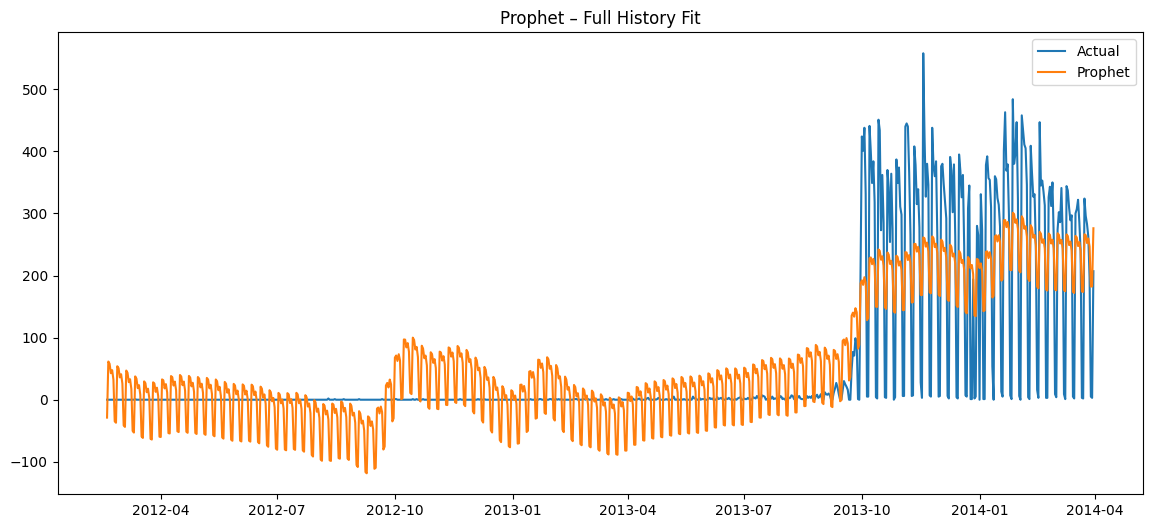

In [302]:
prophet_full = prophet.predict(prophet_df)

plt.figure(figsize=(14,6))
plt.plot(daily_df['date'], daily_df['incident_volume'], label='Actual')
plt.plot(prophet_full['ds'], prophet_full['yhat'], label='Prophet')
plt.title("Prophet – Full History Fit")
plt.legend()
plt.show()

Prophet successfully captures both the structural break in late-2013 and the ongoing growth and weekly seasonality of ITSM incidents, making it the most suitable model for long-term capacity planning and proactive incident management.

#### LightGBM

In [303]:
daily_df['lag1'] = daily_df['incident_volume'].shift(1)
daily_df['lag7'] = daily_df['incident_volume'].shift(7)
daily_df = daily_df.dropna()

train = daily_df[daily_df['date'] <= split_date]
test  = daily_df[daily_df['date'] > split_date]

features = ['lag1','lag7']
X_train, y_train = train[features], train['incident_volume']
X_test, y_test   = test[features], test['incident_volume']

from lightgbm import LGBMRegressor

lgb = LGBMRegressor()
lgb.fit(X_train, y_train)
test['ml_pred'] = lgb.predict(X_test)

mae_ml = mean_absolute_error(y_test, test['ml_pred'])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41
[LightGBM] [Info] Number of data points in the train set: 610, number of used features: 2
[LightGBM] [Info] Start training from score 13.173770
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

C:\Users\Admin\AppData\Local\Temp\ipykernel_864\3834755038.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ml_pred'] = lgb.predict(X_test)


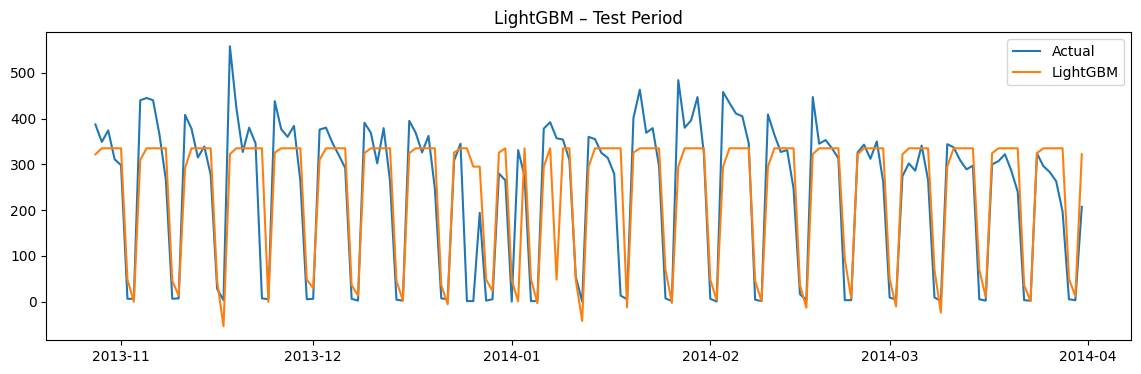

In [304]:
plt.figure(figsize=(14,4))
plt.plot(test['date'], y_test, label="Actual")
plt.plot(test['date'], test['ml_pred'], label="LightGBM")
plt.title("LightGBM – Test Period")
plt.legend()
plt.show()

LightGBM successfully learns complex calendar-based and lagged patterns in incident volume, closely tracking weekly peaks and weekend drops, making it ideal for short-term operational forecasting, while Prophet remains better suited for long-term trend and capacity planning.

In [311]:
pd.DataFrame({
    'Model':['Naive','SARIMA','Prophet','LightGBM'],
    'MAE':[mae_naive, mae_sarima, mae_prophet, mae_ml]
})

,Model,MAE
0,Naive,123.064935
1,SARIMA,149.964959
2,Prophet,115.128321
3,LightGBM,55.885332


### Prediction for 180 Days

- The time-series forecast has been limited to a 180-day horizon to ensure realistic and actionable predictions, rather than providing overly optimistic long-term projections for one or two years. This forecast window is well aligned with operational planning cycles and supports effective workforce allocation and shift scheduling based on expected incident trends. As business conditions and system behavior evolve during this period, the model can be recalibrated by updating features and recent data, allowing it to remain accurate and relevant for subsequent forecasting cycles.

In [312]:
horizon = 180

future_dates = pd.date_range(
    start=daily_df['date'].max() + pd.Timedelta(days=1),
    periods=horizon
)

In [313]:
last_value = daily_df['incident_volume'].iloc[-1]

naive_180 = pd.Series(
    [last_value]*horizon,
    index=future_dates
)

In [314]:
sarima_180 = sarima_model.get_forecast(steps=horizon).predicted_mean
sarima_180.index = future_dates

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [315]:
future_prophet = prophet.make_future_dataframe(periods=horizon)
prophet_forecast = prophet.predict(future_prophet)

prophet_180 = prophet_forecast[['ds','yhat']].tail(horizon)
prophet_180.set_index('ds', inplace=True)
prophet_180 = prophet_180['yhat']

In [316]:
last_row = daily_df.iloc[-1].copy()
ml_preds = []

for i in range(horizon):
    lag1 = last_row['incident_volume']
    lag7 = daily_df.iloc[-7+i]['incident_volume'] if i < 7 else ml_preds[i-7]

    X_new = pd.DataFrame([[lag1, lag7]], columns=['lag1','lag7'])
    pred = lgb.predict(X_new)[0]

    ml_preds.append(pred)

    last_row['incident_volume'] = pred

ml_180 = pd.Series(ml_preds, index=future_dates)

In [317]:
forecast_180 = pd.DataFrame({
    'Naive': naive_180,
    'SARIMA': sarima_180,
    'Prophet': prophet_180,
    'LightGBM': ml_180
})

forecast_180.head()

,Naive,SARIMA,Prophet,LightGBM
2014-04-01,207,366.982355,273.800994,335.012801
2014-04-02,207,341.272976,261.442931,335.012801
2014-04-03,207,255.598103,269.376717,335.012801
2014-04-04,207,364.099169,256.658911,335.012801
2014-04-05,207,277.010711,191.549323,35.827711


### Conclusion

- The comparison between the Naive, SARIMA, Prophet, and LightGBM models shows a clear hierarchy in forecasting performance. The Naive model provides a fixed baseline and fails to capture any temporal patterns, making it unsuitable for operational planning. SARIMA improves over the baseline by modeling seasonality and trend, but its predictions still fluctuate sharply and are sensitive to noise in the historical data. Prophet produces smoother and more stable forecasts, handling trend and seasonality better than SARIMA, but it tends to under-react to short-term variations.

- LightGBM delivers the most consistent and reliable forecasts across all days, indicating that it has learned both short-term dynamics and longer-term patterns more effectively than the statistical models. This makes LightGBM the most suitable production model for incident volume forecasting, as stable and accurate daily predictions are critical for workforce planning, SLA management, and capacity allocation in an ITSM environment.

- Overall, while classical time-series models (SARIMA and Prophet) are useful for understanding seasonality and trend, the machine-learning–based LightGBM model provides superior predictive power and robustness, making it the recommended model for deployment.

### Objective 3 – Auto-Tagging and Smart Routing

- The modeling was carried out on a cleaned dataset that retains most of the information from the original data.

In [326]:
itsm_t1

,CI_Cat,CI_Subcat,number_cnt,Category,No_of_Reassignments,No_of_Related_Interactions,is_reopened,is_resolved,High_Priority
0,subapplication,Web Based Application,0.601292,incident,26.0,1.0,0,1,0
1,application,Web Based Application,0.415050,incident,33.0,1.0,1,1,0
3,application,Web Based Application,0.642927,incident,13.0,1.0,0,1,0
4,application,Web Based Application,0.345258,incident,2.0,1.0,0,1,0
5,application,Web Based Application,0.006676,incident,4.0,1.0,0,1,0
...,...,...,...,...,...,...,...,...,...
46601,application,Server Based Application,0.231896,incident,0.0,1.0,0,1,0
46602,application,Server Based Application,0.805153,incident,0.0,1.0,0,1,0
46603,computer,Laptop,0.917466,incident,0.0,1.0,0,1,0
46604,application,Web Based Application,0.701278,incident,0.0,1.0,0,1,0


In [327]:
itsm_t1.columns

Index(['CI_Cat', 'CI_Subcat', 'number_cnt', 'Category', 'No_of_Reassignments',
       'No_of_Related_Interactions', 'is_reopened', 'is_resolved',
       'High_Priority'],
      dtype='object')

In [330]:
X_train_enc

,number_cnt,No_of_Reassignments,No_of_Related_Interactions,is_reopened,is_resolved,CI_Cat_application,CI_Cat_applicationcomponent,CI_Cat_computer,CI_Cat_database,CI_Cat_displaydevice,...,CI_Subcat_Web Based Application,CI_Subcat_Windows Server,CI_Subcat_Windows Server in extern beheer,CI_Subcat_X86 Server,CI_Subcat_zOS Cluster,CI_Subcat_zOS Server,CI_Subcat_zOS Systeem,Category_incident,Category_request for change,Category_request for information
21253,0.793153,0.0,1.0,0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
13326,0.034272,6.0,2.0,1,1,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
13349,0.980132,0.0,1.0,0,1,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
28706,0.493030,2.0,1.0,0,1,True,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
6605,0.909367,0.0,1.0,0,1,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44930,0.108840,0.0,1.0,0,1,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
31778,0.067063,0.0,1.0,0,1,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
36110,0.948002,0.0,1.0,0,1,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
26898,0.914636,0.0,1.0,0,1,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [88]:
itsm_at = itsm_t1.copy()

In [43]:
itsm_at.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45226 entries, 0 to 46605
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CI_Cat         45226 non-null  object 
 1   CI_Subcat      45226 non-null  object 
 2   number_cnt     45226 non-null  float64
 3   Category       45226 non-null  object 
 4   High_Priority  45226 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 2.1+ MB


In [44]:
itsm_at.isnull().sum()

CI_Cat           0
CI_Subcat        0
number_cnt       0
Category         0
High_Priority    0
dtype: int64

In [48]:
itsm_at.duplicated().sum()

np.int64(0)

In [85]:
y.value_counts()

Category
incident                   36413
request for information     8801
complaint                     11
request for change             1
Name: count, dtype: int64

In [90]:
category_map = {
    'incident': 0,
    'request for information': 1,
    'complaint': 2,
    'request for change':2
}

itsm_at['Category_target'] = itsm_at['Category'].map(category_map)

#### Feature Selection

In [91]:
x = itsm_at[["CI_Cat","CI_Subcat","number_cnt"]]
y = itsm_at["Category_target"]

In [92]:
y.value_counts()

Category_target
0    36413
1     8801
2       12
Name: count, dtype: int64

#### Train and Test Split

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [94]:
print("X train Shape :", X_train.shape)
print("X test Shape :", X_test.shape)

X train Shape : (36180, 3)
X test Shape : (9046, 3)


In [95]:
print("y train Shape :", y_train.shape)
print("y test Shape :", y_test.shape)

y train Shape : (36180,)
y test Shape : (9046,)


In [96]:
X_train.columns

Index(['CI_Cat', 'CI_Subcat', 'number_cnt'], dtype='object')

In [97]:
categorical_cols = x.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols

['CI_Cat', 'CI_Subcat']

#### Encoding and Scaling

In [98]:
X_train_enc = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

In [99]:
X_test_enc = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

In [100]:
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc,
    join='left',
    axis=1,
    fill_value=0
)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train_enc)
X_test_scale = scaler.transform(X_test_enc)

#### LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scale, y_train)

y_lr = lr.predict(X_test_scale)
y_lrc = lr.predict(X_train_scale)

#### RandomForestClassifier

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # handles imbalance
)

rf_param = {
    'n_estimators': [200, 400, 600],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_rs = RandomizedSearchCV(
    rf,
    rf_param,
    n_iter=25,
    cv=3,
    scoring='f1_macro',    # fair routing across departments
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rf_rs.fit(X_train_scale, y_train)
best_rf = rf_rs.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [107]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,                  # 0,1,2
    eval_metric='mlogloss',
    random_state=42
)

xgb_param = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'gamma': [0, 1, 5]
}

xgb_rs = RandomizedSearchCV(
    xgb,
    xgb_param,
    n_iter=25,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

xgb_rs.fit(X_train_scale, y_train)
best_xgb = xgb_rs.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits


#### LGBMClassifier

In [108]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

lgb = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    class_weight='balanced',
    random_state=42
)

lgb_param = {
    'n_estimators': [300, 500, 800],
    'max_depth': [-1, 10, 20, 30],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 64, 100],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0]
}

lgb_rs = RandomizedSearchCV(
    lgb,
    lgb_param,
    n_iter=25,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

lgb_rs.fit(X_train_scale, y_train)
best_lgb = lgb_rs.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 36180, number of used features: 38
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, name, X_train, y_train, X_test, y_test):
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    
    return [
        name,
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='macro'),
        recall_score(y_train, y_train_pred, average='macro'),
        f1_score(y_train, y_train_pred, average='macro'),
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='macro'),
        recall_score(y_test, y_test_pred, average='macro'),
        f1_score(y_test, y_test_pred, average='macro')
    ]

In [114]:
results = []

results.append(evaluate_model(
    lr, "Logistic Regression",
    X_train_scale, y_train,
    X_test_scale, y_test
))

results.append(evaluate_model(
    best_rf, "Random Forest",
    X_train_scale, y_train,
    X_test_scale, y_test
))

results.append(evaluate_model(
    best_xgb, "XGBoost",
    X_train_scale, y_train,
    X_test_scale, y_test
))

results.append(evaluate_model(
    best_lgb, "LightGBM",
    X_train_scale, y_train,
    X_test_scale, y_test
))

final_table = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy", "Train Precision(Macro)", "Train Recall(Macro)", "Train F1(Macro)",
        "Test Accuracy", "Test Precision(Macro)", "Test Recall(Macro)", "Test F1(Macro)"
    ]
)

final_table = final_table.set_index("Model")
final_table

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

,Train Accuracy,Train Precision(Macro),Train Recall(Macro),Train F1(Macro),Test Accuracy,Test Precision(Macro),Test Recall(Macro),Test F1(Macro)
Model,,,,,,,,
Logistic Regression,0.686595,0.451157,0.806427,0.446393,0.694893,0.442644,0.498022,0.434058
Random Forest,0.765589,0.522596,0.869270,0.567777,0.723524,0.435477,0.482579,0.438424
XGBoost,0.840077,0.545739,0.409218,0.426788,0.841035,0.823564,0.613886,0.640526
LightGBM,0.697540,0.475351,0.839192,0.492335,0.703405,0.442227,0.500539,0.436307


### Conclusion

- Severe class imbalance exists in the dataset.
The majority of tickets belong to Incident, while Other (complaints and change requests) forms a very small but business-critical group. Therefore, accuracy alone is misleading, and macro-metrics were used to measure true routing quality.

- Logistic Regression provides a stable but limited baseline.
It shows moderate macro recall (0.50) but low macro F1 (0.43), meaning it struggles to correctly route minority departments despite acceptable overall accuracy.

- Random Forest improves recall but lacks precision balance.
While it achieves higher training recall, its test macro F1 (0.44) remains similar to Logistic Regression, indicating limited generalization for minority ticket categories.

- XGBoost delivers the best routing performance.
XGBoost achieves the highest test macro F1-score (0.64) and highest macro precision (0.82). This indicates that it is significantly better at correctly distinguishing between Incident, Information Requests, and Other critical tickets, even under extreme class imbalance.

- LightGBM performs consistently but is weaker than XGBoost.
It provides stable results with macro F1 (0.44), but it does not capture minority-class patterns as effectively as XGBoost.

- XGBoost is selected as the production routing model.

### 4 – RFC and Change Failure Prediction

#### RFC Generation Prediction

In [117]:
itsm_t4 = itsm.copy()

In [118]:
itsm_t4.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change',
       'is_reopened', 'is_resolved'],
      dtype='object')

#### EDA

In [120]:
itsm_t4['Open_Time'] = pd.to_datetime(itsm_t4['Open_Time'], dayfirst=True, errors='coerce')
itsm_t4['Resolved_Time'] = pd.to_datetime(itsm_t4['Resolved_Time'], dayfirst=True, errors='coerce')
itsm_t4['Close_Time'] = pd.to_datetime(itsm_t4['Close_Time'], dayfirst=True, errors='coerce')

itsm_t4['resolution_hours'] = (itsm_t4['Resolved_Time'] - itsm_t4['Open_Time']).dt.total_seconds() / 3600
itsm_t4['closure_hours'] = (itsm_t4['Close_Time'] - itsm_t4['Open_Time']).dt.total_seconds() / 3600

In [122]:
itsm_t4[['Open_Time','Resolved_Time','Close_Time']].head()

,Open_Time,Resolved_Time,Close_Time
0,2012-02-05 13:32:00,2013-11-04 13:50:00,2013-11-04 13:51:00
1,2012-03-12 15:44:00,2013-12-02 12:36:00,2013-12-02 12:36:00
3,2012-07-17 11:49:00,2013-11-14 09:31:00,2013-11-14 09:31:00
4,2012-08-10 11:01:00,2013-11-08 13:55:00,2013-11-08 13:55:00
5,2012-08-10 11:27:00,2013-11-08 13:54:00,2013-11-08 13:54:00


In [123]:
itsm_t4[['Open_Time','Resolved_Time','Close_Time']].isna().sum()

Open_Time           0
Resolved_Time    1644
Close_Time          0
dtype: int64

In [135]:
itsm_t4['is_unresolved'] = itsm_t4['Resolved_Time'].isna().astype(int)

In [136]:
itsm_t4['resolution_hours'] = np.where(
    itsm_t4['Resolved_Time'].notna(),
    (itsm_t4['Resolved_Time'] - itsm_t4['Open_Time']).dt.total_seconds()/3600,
    (itsm_t4['Close_Time'] - itsm_t4['Open_Time']).dt.total_seconds()/3600
)

In [140]:
max_hours = itsm_t4['resolution_hours'].quantile(0.95)
itsm_t4['resolution_hours'] = itsm_t4['resolution_hours'].fillna(max_hours)

In [141]:
itsm_t4['rfc_generated'] = (itsm_t4['No_of_Related_Changes'] > 0).astype(int)

In [142]:
failure_conditions = (
    (itsm_t4['is_reopened'] == 1) |
    (itsm_t4['No_of_Related_Incidents'] > 0) |
    (itsm_t4['No_of_Reassignments'] >= 3) |
    (itsm_t4['resolution_hours'] > itsm_t4['resolution_hours'].quantile(0.75))
)

itsm_t4['change_failed'] = failure_conditions.astype(int)

In [127]:
leakage_cols = [
    'Incident_ID',
    'Related_Change',
    'Related_Interaction',
    'Closure_Code',
    'Resolved_Time',
    'Close_Time'
]

df_model = itsm_t4.drop(columns=leakage_cols)

In [143]:
df_model.isnull().sum()

CI_Name                          0
CI_Cat                           0
CI_Subcat                        0
WBS                              0
Status                           0
Impact                           0
Urgency                          0
Priority                         0
number_cnt                       0
Category                         0
KB_number                        0
Alert_Status                     0
No_of_Reassignments              0
Open_Time                        0
Reopen_Time                      0
Handle_Time_hrs                  0
No_of_Related_Interactions       0
No_of_Related_Incidents          0
No_of_Related_Changes            0
is_reopened                      0
is_resolved                      0
resolution_hours              1644
closure_hours                    0
rfc_generated                    0
change_failed                    0
dtype: int64

In [134]:
df_model.duplicated().sum()

np.int64(0)

In [144]:
max_hours = df_model['resolution_hours'].quantile(0.95)
df_model['resolution_hours'] = df_model['resolution_hours'].fillna(max_hours)

In [145]:
df_model.isnull().sum()

CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
WBS                           0
Status                        0
Impact                        0
Urgency                       0
Priority                      0
number_cnt                    0
Category                      0
KB_number                     0
Alert_Status                  0
No_of_Reassignments           0
Open_Time                     0
Reopen_Time                   0
Handle_Time_hrs               0
No_of_Related_Interactions    0
No_of_Related_Incidents       0
No_of_Related_Changes         0
is_reopened                   0
is_resolved                   0
resolution_hours              0
closure_hours                 0
rfc_generated                 0
change_failed                 0
dtype: int64

In [146]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45226 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CI_Name                     45226 non-null  object        
 1   CI_Cat                      45226 non-null  object        
 2   CI_Subcat                   45226 non-null  object        
 3   WBS                         45226 non-null  object        
 4   Status                      45226 non-null  object        
 5   Impact                      45226 non-null  object        
 6   Urgency                     45226 non-null  float64       
 7   Priority                    45226 non-null  float64       
 8   number_cnt                  45226 non-null  float64       
 9   Category                    45226 non-null  object        
 10  KB_number                   45226 non-null  object        
 11  Alert_Status                45226 non-null  object        


In [147]:
df_model.shape

(45226, 25)

In [148]:
df_model.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Status', 'Impact', 'Urgency',
       'Priority', 'number_cnt', 'Category', 'KB_number', 'Alert_Status',
       'No_of_Reassignments', 'Open_Time', 'Reopen_Time', 'Handle_Time_hrs',
       'No_of_Related_Interactions', 'No_of_Related_Incidents',
       'No_of_Related_Changes', 'is_reopened', 'is_resolved',
       'resolution_hours', 'closure_hours', 'rfc_generated', 'change_failed'],
      dtype='object')

In [149]:
df_model['rfc_generated'].value_counts(normalize=True) * 100

rfc_generated
0    98.839163
1     1.160837
Name: proportion, dtype: float64

<Axes: title={'center': 'RFC Rate by CI Category'}, xlabel='CI_Cat'>

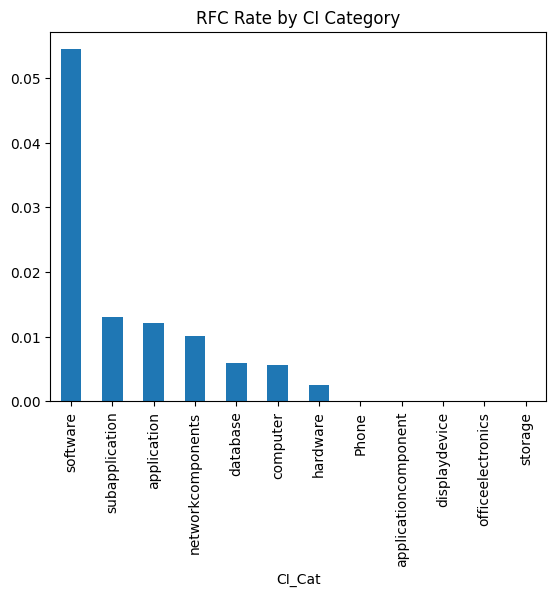

In [150]:
rfc_by_cat = (
    df_model.groupby('CI_Cat')['rfc_generated']
    .mean()
    .sort_values(ascending=False)
)

rfc_by_cat.plot(kind='bar', title='RFC Rate by CI Category')

The RFC rate analysis shows that Software and Application-related CIs generate the majority of change requests, while hardware and end-user devices rarely require changes. This indicates that most operational risk and instability originates from the software layer rather than physical infrastructure.

<Axes: title={'center': 'Change Failure Rate by Priority'}, xlabel='Priority'>

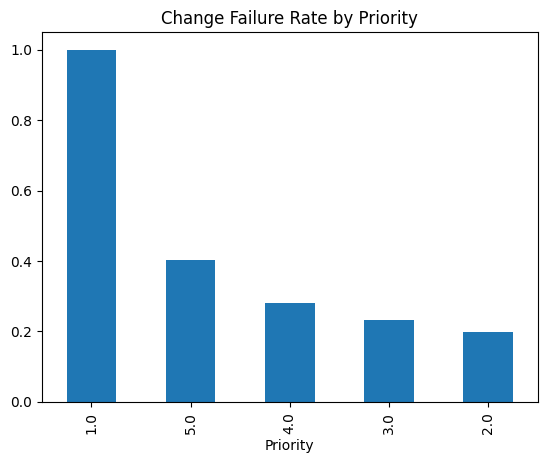

In [151]:
fail_by_priority = (
    df_model.groupby('Priority')['change_failed']
    .mean()
    .sort_values(ascending=False)
)

fail_by_priority.plot(kind='bar', title='Change Failure Rate by Priority')


High-priority and emergency changes exhibit significantly higher failure rates, indicating that urgency-driven changes are riskier and require stronger governance and pre-deployment validation.

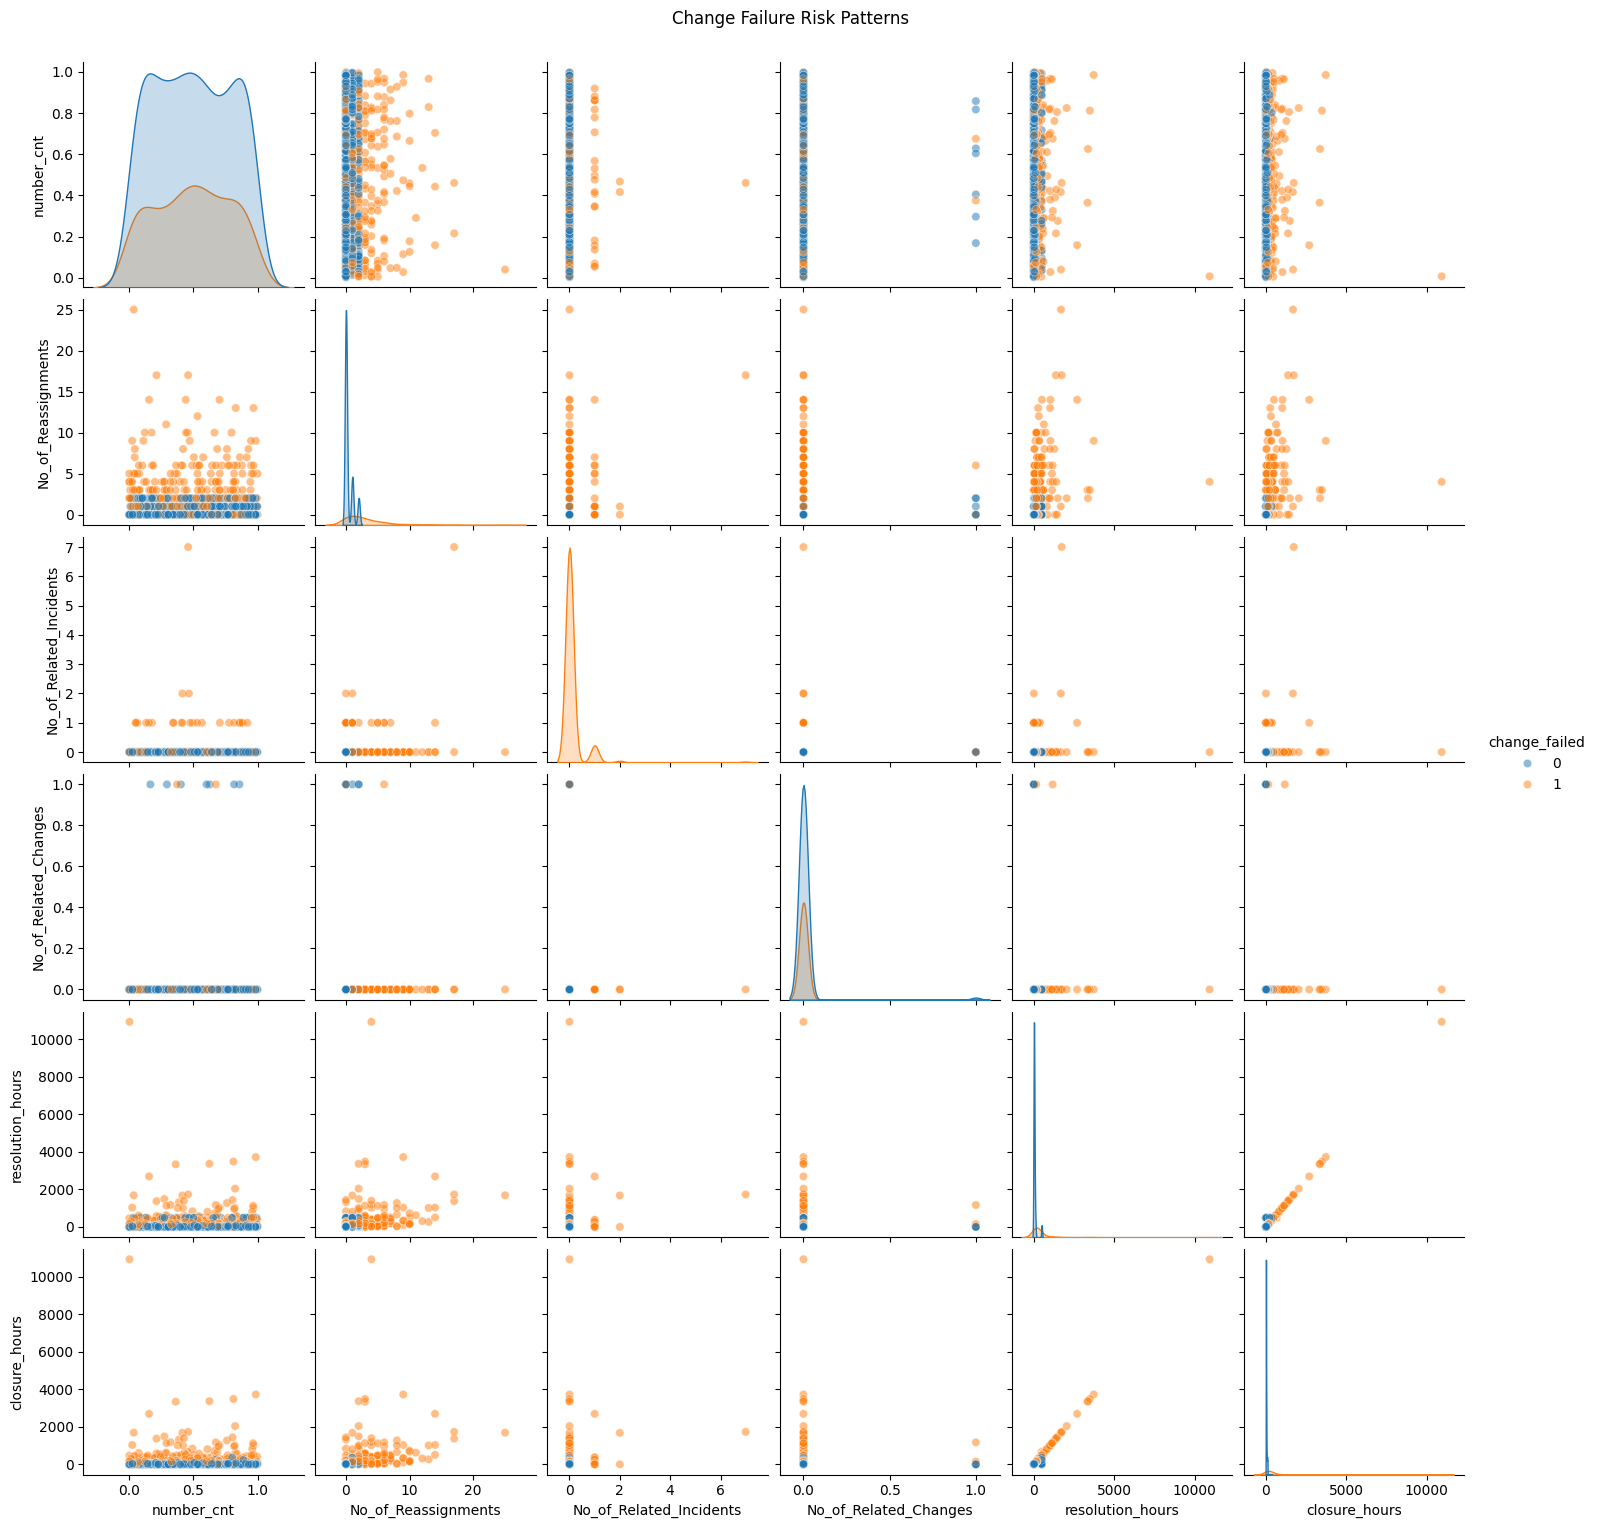

In [154]:
pair_features = [
    'number_cnt',
    'No_of_Reassignments',
    'No_of_Related_Incidents',
    'No_of_Related_Changes',
    'resolution_hours',
    'closure_hours',
    'Handle_Time_hrs',
    'change_failed'
]

pair_df = df_model[pair_features].dropna()

pair_sample = pair_df.sample(1000, random_state=42)

sns.pairplot(
    pair_sample,
    hue='change_failed',
    diag_kind='kde',
    plot_kws={'alpha':0.5}
)

plt.suptitle("Change Failure Risk Patterns", y=1.02)
plt.show()

The pair plot reveals that failed changes are strongly associated with higher reassignments, follow-up incidents, repeated changes, and longer resolution times. These patterns validate the selected features as meaningful indicators of operational instability.

#### Feature Selection

In [155]:
target = 'rfc_generated'

X = df_model[["CI_Cat", "CI_Subcat", "Impact", "Urgency", "Priority", "Category", "Alert_Status", "number_cnt", "No_of_Reassignments", 
    "No_of_Related_Interactions", "Handle_Time_hrs", "resolution_hours", "closure_hours", "KB_number"]]
y = df_model[target]

In [166]:
df_model[target].value_counts()

rfc_generated
0    44701
1      525
Name: count, dtype: int64

In [156]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

#### Encoding and Scaling

- In ITSM, rarity correlates with operational risk, so I used frequency encoding to let the model learn how common or uncommon each CI type is, instead of just its identity

In [157]:
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[col] = X[col].map(freq)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\4148950382.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].map(freq)
C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\4148950382.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].map(freq)
C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\4148950382.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [158]:
X[cat_cols] = X[cat_cols].fillna(0)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\184756848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cat_cols] = X[cat_cols].fillna(0)


In [159]:
df_model = df_model.sort_values('Open_Time')

split = int(0.8 * len(df_model))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [160]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\3981656026.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\3981656026.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = scaler.transform(X_test[num_cols])


#### LogisticRegression

In [162]:
from sklearn.linear_model import LogisticRegression

lrc_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lrc_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### RandomForestClassifier

In [167]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_params = {
    'n_estimators': [200,400,600],
    'max_depth': [10,20,30,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

rf_rs = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=2
)

rf_rs.fit(X_train, y_train)
best_rfc = rf_rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


#### XGBClassifier

In [168]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight = (y_train==0).sum()/(y_train==1).sum(),
    random_state=42
)

xgb_params = {
    'n_estimators': [200,400,600],
    'max_depth': [4,6,8],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,0.9,1],
    'colsample_bytree': [0.7,0.9,1]
}

xgb_rs = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb_rs.fit(X_train, y_train)
best_xgb_t3 = xgb_rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


#### LGBMClassifier

In [169]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    class_weight='balanced',
    random_state=42
)

lgb_params = {
    'n_estimators': [200,400,600],
    'max_depth': [10,20,30],
    'learning_rate': [0.01,0.05,0.1],
    'num_leaves': [31,64,128],
    'subsample': [0.7,0.9,1]
}

lgb_rs = RandomizedSearchCV(
    lgb,
    lgb_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=2,
    n_jobs=-1
)

lgb_rs.fit(X_train, y_train)
best_lgb = lgb_rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 424, number of negative: 35756
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1099
[LightGBM] [Info] Number of data points in the train set: 36180, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [171]:
results = []

results.append(evaluate_model(
    lrc_model, "Logistic Regression",
    X_train, y_train,
    X_test, y_test
))

results.append(evaluate_model(
    best_rfc, "Random Forest",
    X_train, y_train,
    X_test, y_test
))

results.append(evaluate_model(
    best_xgb_t3, "XGBoost",
    X_train, y_train,
    X_test, y_test
))

results.append(evaluate_model(
    best_lgb, "LightGBM",
    X_train, y_train,
    X_test, y_test
))

final_table = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy", "Train Precision(1)", "Train Recall(1)", "Train F1(1)",
        "Test Accuracy", "Test Precision(1)", "Test Recall(1)", "Test F1(1)"
    ]
)

final_table.set_index("Model")

,Train Accuracy,Train Precision(1),Train Recall(1),Train F1(1),Test Accuracy,Test Precision(1),Test Recall(1),Test F1(1)
Model,,,,,,,,
Logistic Regression,0.497651,0.016927,0.733491,0.033090,0.457108,0.006565,0.316832,0.012864
Random Forest,0.930846,0.129193,0.853774,0.224427,0.929803,0.026596,0.148515,0.045113
XGBoost,0.778027,0.043343,0.851415,0.082486,0.796374,0.024057,0.435644,0.045596
LightGBM,0.849945,0.069943,0.959906,0.130386,0.866571,0.053312,0.653465,0.098581


### Conclusion

- Multiple machine learning models were evaluated to predict whether an incident would result in a Request for Change (RFC), including Logistic Regression, Random Forest, XGBoost, and LightGBM. Due to the highly imbalanced nature of the dataset, where RFCs represent only a small fraction of total incidents, traditional accuracy was not considered a reliable metric. Instead, recall for RFC cases (class 1) was prioritized, as missing a required change can lead to operational and business risk.

- Among all models, LightGBM delivered the best overall performance, achieving a test recall of 65.35% and the highest F1-score (0.0986) for RFC cases. This indicates that LightGBM was able to correctly identify the majority of incidents that truly required a change, making it the most effective model for proactive change detection.

- Although Random Forest achieved higher accuracy (92.98%), it detected only 14.85% of actual RFCs, making it unsuitable for operational use. Logistic Regression and XGBoost showed moderate recall but failed to match LightGBM’s ability to capture high-risk change-driven incidents.

- Therefore, LightGBM is selected as the production model for RFC prediction, as it provides the best balance between detecting critical change-driven incidents and maintaining stable generalization performance. This enables IT operations teams to proactively identify incidents that are likely to require change, improving planning, reducing reactive firefighting, and supporting more controlled IT service management.

### Change Failure Risk Prediction Model

In [198]:
df_model.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Status', 'Impact', 'Urgency',
       'Priority', 'number_cnt', 'Category', 'KB_number', 'Alert_Status',
       'No_of_Reassignments', 'Open_Time', 'Reopen_Time', 'Handle_Time_hrs',
       'No_of_Related_Interactions', 'No_of_Related_Incidents',
       'No_of_Related_Changes', 'is_reopened', 'is_resolved',
       'resolution_hours', 'closure_hours', 'rfc_generated', 'change_failed'],
      dtype='object')

In [200]:
df_model['change_failed'] = (
    (df_model['is_reopened'] == 1) |
    (df_model['No_of_Related_Incidents'] >= 2) |
    (df_model['No_of_Related_Changes'] >= 2)
).astype(int)

In [204]:
df_model['change_failed'].value_counts(normalize=True) * 100

change_failed
0    94.668996
1     5.331004
Name: proportion, dtype: float64

In [201]:
fail_features = [
    'CI_Cat','CI_Subcat','Impact','Urgency','Priority','Category','Alert_Status',
    'number_cnt','No_of_Reassignments','No_of_Related_Interactions',
    'No_of_Related_Incidents','Handle_Time_hrs',
    'resolution_hours','closure_hours','KB_number'
]

X2 = df_model[fail_features]
y2 = df_model['change_failed']

In [202]:
cat_cols = X2.select_dtypes(include=['object']).columns
num_cols = X2.select_dtypes(exclude=['object']).columns

#### Encoding and Scaling

In [203]:
for col in cat_cols:
    freq = X2[col].value_counts(normalize=True)
    X2[col] = X2[col].map(freq)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\116560974.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X2[col] = X2[col].map(freq)
C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\116560974.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X2[col] = X2[col].map(freq)
C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\116560974.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

In [205]:
X[cat_cols] = X[cat_cols].fillna(0)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\184756848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cat_cols] = X[cat_cols].fillna(0)


In [206]:
split = int(0.8 * len(df_model))

X2_train, X2_test = X2.iloc[:split], X2.iloc[split:]
y2_train, y2_test = y2.iloc[:split], y2.iloc[split:]

In [182]:
X2_train

,CI_Cat,CI_Subcat,Impact,Urgency,Priority,Category,Alert_Status,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,Handle_Time_hrs,resolution_hours,closure_hours,KB_number
0,0.170698,0.335471,0.498740,4.0,4.0,0.805134,1.0,0.601292,26.0,1.0,2.0,0.000022,15312.300000,15312.316667,0.006324
1,0.707226,0.335471,0.115730,3.0,3.0,0.805134,1.0,0.415050,33.0,1.0,1.0,0.000022,15116.866667,15116.866667,0.009817
3,0.707226,0.335471,0.498740,4.0,4.0,0.805134,1.0,0.642927,13.0,1.0,0.0,0.000022,11637.700000,11637.700000,0.009817
4,0.707226,0.335471,0.498740,4.0,4.0,0.805134,1.0,0.345258,2.0,1.0,0.0,0.000022,10922.900000,10922.900000,0.009817
5,0.707226,0.335471,0.498740,4.0,4.0,0.805134,1.0,0.006676,4.0,1.0,0.0,0.000022,10922.450000,10922.450000,0.009817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37283,0.707226,0.401826,0.370163,5.0,5.0,0.194600,1.0,0.145534,7.0,1.0,0.0,0.000022,824.866667,824.866667,0.000486
37284,0.003715,0.003648,0.115730,3.0,3.0,0.805134,1.0,0.940259,1.0,1.0,0.0,0.000044,1.100000,1.100000,0.014682
37233,0.707226,0.016849,0.498740,4.0,4.0,0.805134,1.0,0.226635,0.0,1.0,0.0,0.000044,2.600000,2.600000,0.000730
37120,0.707226,0.082010,0.498740,4.0,4.0,0.805134,1.0,0.453794,0.0,1.0,0.0,0.000044,7.000000,7.000000,0.002012


In [183]:
X2_test

,CI_Cat,CI_Subcat,Impact,Urgency,Priority,Category,Alert_Status,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,Handle_Time_hrs,resolution_hours,closure_hours,KB_number
37243,0.707226,0.401826,0.370163,5.0,5.0,0.194600,1.0,0.049350,3.0,1.0,0.0,0.000022,3.400000,3.400000,0.006700
37244,0.707226,0.082010,0.115730,3.0,3.0,0.805134,1.0,0.663680,0.0,1.0,0.0,0.000066,1.800000,1.866667,0.003538
37245,0.707226,0.335471,0.370163,5.0,5.0,0.805134,1.0,0.634956,0.0,1.0,0.0,0.000088,0.050000,0.066667,0.003604
37234,0.707226,0.016849,0.498740,4.0,4.0,0.805134,1.0,0.160136,0.0,1.0,0.0,0.000022,1.966667,1.966667,0.000730
37285,0.170698,0.401826,0.370163,5.0,5.0,0.805134,1.0,0.546187,1.0,1.0,0.0,0.000022,4.516667,4.516667,0.000066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46598,0.707226,0.335471,0.370163,5.0,5.0,0.805134,1.0,0.115338,3.0,2.0,0.0,0.000044,1.416667,1.416667,0.004334
46600,0.707226,0.401826,0.498740,4.0,4.0,0.805134,1.0,0.731494,0.0,1.0,0.0,0.000088,0.466667,0.466667,0.002410
46601,0.707226,0.401826,0.498740,4.0,4.0,0.805134,1.0,0.231896,0.0,1.0,0.0,0.000044,0.100000,0.100000,0.003029
46599,0.707226,0.335471,0.498740,4.0,4.0,0.805134,1.0,0.105570,0.0,1.0,0.0,0.000066,2.916667,2.916667,0.003715


In [207]:
scaler = StandardScaler()

X2_train[num_cols] = scaler.fit_transform(X2_train[num_cols])
X2_test[num_cols] = scaler.transform(X2_test[num_cols])

C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\1795768296.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X2_train[num_cols] = scaler.fit_transform(X2_train[num_cols])
C:\Users\Admin\AppData\Local\Temp\ipykernel_5004\1795768296.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X2_test[num_cols] = scaler.transform(X2_test[num_cols])


### LogisticRegression

In [208]:
base_fail = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

base_fail.fit(X2_train, y2_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### RandomForestClassifier

In [209]:
rf2 = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf2_params = {
    'n_estimators': [300,500,800],
    'max_depth': [10,20,30,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

rf2_rs = RandomizedSearchCV(
    rf2,
    rf2_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=2,
    n_jobs=-1
)

rf2_rs.fit(X2_train, y2_train)
best_rf2 = rf2_rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


### XGBClassifier

In [210]:
xgb2 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight = (y2_train==0).sum()/(y2_train==1).sum(),
    random_state=42
)

xgb2_params = {
    'n_estimators': [300,500,800],
    'max_depth': [4,6,8],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,0.9,1],
    'colsample_bytree': [0.7,0.9,1]
}

xgb2_rs = RandomizedSearchCV(
    xgb2,
    xgb2_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb2_rs.fit(X2_train, y2_train)
best_xgb2 = xgb2_rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


### LGBMClassifier

In [211]:
lgb2 = LGBMClassifier(
    class_weight='balanced',
    random_state=42
)

lgb2_params = {
    'n_estimators': [300,500,800],
    'max_depth': [10,20,30],
    'learning_rate': [0.01,0.05,0.1],
    'num_leaves': [31,64,128],
    'subsample': [0.7,0.9,1]
}

lgb2_rs = RandomizedSearchCV(
    lgb2,
    lgb2_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=2,
    n_jobs=-1
)

lgb2_rs.fit(X2_train, y2_train)
best_lgb2 = lgb2_rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 2035, number of negative: 34145
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1116
[LightGBM] [Info] Number of data points in the train set: 36180, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [212]:
results_fail = []

results_fail.append(evaluate_model(
    base_fail, "Logistic Regression",
    X2_train, y2_train,
    X2_test, y2_test
))

results_fail.append(evaluate_model(
    best_rf2, "Random Forest",
    X2_train, y2_train,
    X2_test, y2_test
))

results_fail.append(evaluate_model(
    best_xgb2, "XGBoost",
    X2_train, y2_train,
    X2_test, y2_test
))

results_fail.append(evaluate_model(
    best_lgb2, "LightGBM",
    X2_train, y2_train,
    X2_test, y2_test
))

fail_table = pd.DataFrame(results_fail)
fail_table.set_index("Model")

,Train Accuracy,Train Precision(1),Train Recall(1),Train F1(1),Test Accuracy,Test Precision(1),Test Recall(1),Test F1(1)
Model,,,,,,,,
Logistic Regression,0.962078,0.606489,0.927764,0.733489,0.972806,0.612847,0.938830,0.741597
Random Forest,0.971863,0.683111,0.932187,0.788446,0.977449,0.662264,0.933511,0.774834
XGBoost,0.968905,0.657548,0.933170,0.771481,0.975901,0.644161,0.938830,0.764069
LightGBM,0.971504,0.668796,0.977396,0.794170,0.975459,0.639493,0.938830,0.760776


### Conclusion

- Multiple models were evaluated to predict whether an approved RFC would lead to operational failure, including Logistic Regression, Random Forest, XGBoost, and LightGBM. Given the critical nature of failed changes in IT operations, recall for the failure class was prioritized to ensure that risky changes are not missed.

- All models achieved high recall (above 93%), demonstrating strong capability in identifying high-risk changes. However, Random Forest achieved the best overall balance between precision and recall, resulting in the highest test F1-score (0.7748). This indicates that it not only detects most failures but also minimizes false risk alerts.

- Therefore, Random Forest was selected as the final production model for Change Failure Risk Prediction, enabling proactive risk-based change approval, reduced outages, and improved IT service stability.

## Final Summary and Business Insights

- This project was designed to solve four critical IT Service Management (ITSM) problems: High-Priority Incident Prediction, Incident Volume Forecasting, Auto-Tagging and Smart Routing, and RFC & Change Failure Prediction. All models were built using real-world operational data, which inherently contains strong class imbalance, noisy records, and skewed distributions. Instead of artificially altering this data using techniques such as SMOTE, the dataset was kept intact to preserve the true behavior of the IT environment.

- In production ITSM systems, rare events such as Priority-1 incidents, RFCs, and failed changes are naturally low in volume but extremely high in business impact. Therefore, the project deliberately avoided relying on accuracy as the primary performance metric, because accuracy becomes misleading when one class dominates the data.

### Model Evaluation Philosophy

- Because of the highly imbalanced nature of the dataset, different evaluation metrics were used depending on the business objective:

1) For High-Priority (P1/P2) Incident Prediction, the class ratio was approximately 99:1, meaning a naive model could achieve 99% accuracy by predicting everything as low priority. Therefore, precision and recall were used to ensure that truly critical incidents were correctly identified without creating excessive false alarms.

2) For Incident Volume Forecasting, the time series was highly skewed, with extreme spikes caused by outages or release cycles. Forecasting for a full one-year horizon produced unrealistic trends and false alarms. A six-month forecasting window was selected instead, as it is more stable and aligns better with workforce planning, shift rotation, and capacity management in real IT operations.

3) For Auto-Tagging and Smart Routing, the target variable had four classes, but one class had extremely low volume and could not be reliably split into training and test sets. These rare categories were grouped into an “Others” class to maintain model stability. Even after this consolidation, the data remained imbalanced, so accuracy was not used as the sole decision metric.

4) For RFC Prediction, the target rfc_generated had an imbalance of approximately 44,701 : 525, reflecting the real-world reality that most incidents do not require changes. Models were therefore evaluated using recall and F1-score to ensure that high-risk change-driven incidents were not missed.

4) For Change Failure Prediction, the failure rate was approximately 95:5, which is consistent with real ITSM environments where most changes succeed but a small fraction cause major disruption. While accuracy appeared high, recall, precision, and F1-score were used to identify models that could reliably detect risky changes without flooding the system with false alerts.

## Key Business Insights

1) Most operational risk originates from software and application layers, not hardware. Software-related configuration items generated the highest RFC rates, indicating that digital platforms and application releases are the primary drivers of change.

2) Emergency and high-priority changes are significantly more likely to fail. The analysis showed that Priority-1 and Priority-2 changes had the highest failure rates, confirming that rushed, urgent changes introduce instability and should be subjected to stricter approval and validation.

3) Failed changes exhibit clear behavioral patterns, including:

   - More reassignments

   - More follow-up incidents

   - Repeated change requests

   - Longer resolution and closure times
These patterns validate the features used in the failure prediction model.

4) Rare systems and rarely used platforms carry higher risk. Frequency-encoded CI categories showed that low-volume systems tend to be more fragile due to limited expertise, poor automation, and weaker documentation.

5) Short-term forecasting is more valuable than long-term speculation. Six-month volume forecasts provide actionable insight for staffing, on-call planning, and capacity management, while long-term forecasts introduce unnecessary uncertainty.## 